# Norman 2019 — Main Figure

Runs SHERLOCK (`l0_lambda=25, rank=6, synergy=True`) `N_RUNS` times on the held-out Norman split,
selects the best model by held-out combo ATE, and assembles a four-panel journal figure:

| Panel | Content |
|---|---|
| **(a)** | Counterfactual ATE across N runs — reproducibility & OOD generalisation |
| **(b)** | Single-perturbation latent UMAP (best model) |
| **(c)** | Parent-coefficient scatter (c₁ vs c₂) coloured by Norman GT class |
| **(d)** | GI classification AUC-ROC per class — SHERLOCK vs GEARS |

The notebook saves every intermediate result to `results/norman_figure/` and the final
composite figure to `results/norman_figure/main_figure.pdf`.

In [1]:
import os, sys, math, random, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler

import scanpy as sc
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import torch

sys.path.append('../../..')
import sherlock as slk
from sherlock.tools._models import classify_gi

# ── Journal figure style ────────────────────────────────────────────────
RC = {
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':             8,
    'axes.labelsize':        8,
    'axes.titlesize':        9,
    'xtick.labelsize':       7,
    'ytick.labelsize':       7,
    'legend.fontsize':       7,
    'legend.title_fontsize': 7,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.linewidth':        0.75,
    'xtick.major.width':     0.75,
    'ytick.major.width':     0.75,
    'xtick.major.size':      3,
    'ytick.major.size':      3,
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'pdf.fonttype':          42,
    'ps.fonttype':           42,
}
mpl.rcParams.update(RC)

# ── Colour palette ─────────────────────────────────────────────────────
CLR_SHERLOCK = '#2166ac'
CLR_GEARS    = '#d73027'

# Keys match the exact strings in genetic_interactions.csv
PALETTE_GI = {
    'approximately additive':         '#4DAF4A',  # green
    'epistasis':                      '#FF7F00',  # orange
    'neomorphic':                     '#984EA3',  # purple
    'potentiation':                   '#F781BF',  # pink
    'redundant':                      '#A65628',  # brown
    'suppression':                    '#E41A1C',  # red
    'synergy (dissimilar phenotype)': '#377EB8',  # blue
    'synergy (similar phenotype)':    '#6BAED6',  # light blue
}

# ── Constants ──────────────────────────────────────────────────────────
N_RUNS    = 3
SEED_BASE = 0
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT_DIR   = Path('./results/norman_figure')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}  |  N_RUNS: {N_RUNS}  |  Output: {OUT_DIR}')

Device: cuda  |  N_RUNS: 3  |  Output: results/norman_figure


## 1. Load and preprocess Norman 2019

In [2]:
data = sc.read_h5ad('../../datasets/norman/Norman_2019.h5ad')
data.X = data.layers['counts'].copy()

slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f'Cells: {data.n_obs}  |  Genes: {data.n_vars}')
print(f'Single perts: {len(single_perts)}  |  Combo perts: {len(combo_perts)}')

Cells: 111255  |  Genes: 19018
Single perts: 105  |  Combo perts: 131


In [3]:
# Gene filtering: keep genes with mean count > 0.5 UMI or that are pert targets
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

mean_expr = np.array(data.X.mean(axis=0)).flatten()
expr_mask = mean_expr > 0.5
pert_mask = data.var_names.isin(pert_genes)
keep_mask = expr_mask | pert_mask
data = data[:, keep_mask].copy()

print(f'Kept {data.n_vars} genes  '
      f'({expr_mask[keep_mask].sum()} expr + '
      f'{(pert_mask[keep_mask] & ~expr_mask[keep_mask]).sum()} pert-only)')

Kept 3270 genes  (3190 expr + 80 pert-only)


In [4]:
# Observed treatment effects (log2-CPM vs NTC baseline)
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f'treat_effect: {te.n_obs} perturbations × {te.n_vars} genes')

100%|██████████| 236/236 [00:04<00:00, 52.94it/s]

treat_effect: 236 perturbations × 3270 genes


## 2. Train/val split — 20% of each Norman GT class held out

In [5]:
def canon_pair(s):
    s = str(s)
    if '+' not in s:
        return s
    a, b = s.split('+', 1)
    return '+'.join(sorted([a.strip(), b.strip()]))

random.seed(42)
gi_labels = pd.read_csv('./genetic_interactions.csv')
gi_labels['combination'] = gi_labels['combination'].apply(canon_pair)
gi_labels['genetic_interaction'] = gi_labels['genetic_interaction'].str.strip()

val_combos = set()
for cls, grp in gi_labels.groupby('genetic_interaction'):
    n_val = math.ceil(0.2 * len(grp))
    val_combos.update(random.sample(list(grp['combination']), n_val))

val_mask   = data.obs[p_key].apply(lambda p: ('+' in str(p)) and (canon_pair(p) in val_combos))
data_train = data[~val_mask].copy()

print(f'Total cells: {data.n_obs}  |  Training: {data_train.n_obs}')
print(f'GT pairs: {len(gi_labels)}  |  Held-out val combos: {len(val_combos)}')

Total cells: 111255  |  Training: 104626
GT pairs: 88  |  Held-out val combos: 22


## 3. Multi-run training

Trains SHERLOCK `N_RUNS` times with identical settings. After each run, computes ATE on
the full data (including held-out combos). The best run by held-out combo ATE is used for
UMAP, synergy analysis, and GI classification.

In [6]:
def _ate_r(pred_df, obs_df, idx):
    idx = [p for p in idx if p in pred_df.index and p in obs_df.index]
    if len(idx) < 2:
        return float('nan')
    x = pred_df.loc[idx].values.ravel()
    y = obs_df.loc[idx].values.ravel()
    v = np.isfinite(x) & np.isfinite(y)
    return float(pearsonr(x[v], y[v])[0]) if v.sum() > 2 else float('nan')


def _effect_size_r(pred_df, obs_df):
    common = pred_df.index.intersection(obs_df.index)
    if len(common) < 3:
        return float('nan')
    p_norms = pred_df.loc[common].apply(np.linalg.norm, axis=1).values
    o_norms = obs_df.loc[common].apply(np.linalg.norm, axis=1).values
    v = np.isfinite(p_norms) & np.isfinite(o_norms)
    return float(pearsonr(p_norms[v], o_norms[v])[0]) if v.sum() > 2 else float('nan')


def _w_coactivation(W, threshold=0.5):
    W_bin = (W > threshold).astype(float)
    dot   = W_bin @ W_bin.T
    norms = np.sqrt(np.diag(dot))
    denom = np.outer(norms, norms) + 1e-8
    cos   = dot / denom
    mask  = ~np.eye(len(norms), dtype=bool)
    return float(cos[mask].mean()) if mask.any() else float('nan')


def _compute_ate_metrics(model, data, val_combos):
    """Compute all ATE breakdown metrics for a model on full data."""
    ate  = model.predict_counterfactual_effects(
        data, n_centroids=25, observed_effect=data.uns['treat_effect'],
    )
    pred = ate['predicted_df']
    obs  = ate['observed_df']
    singles = [p for p in pred.index if '+' not in str(p)]
    combos  = [p for p in pred.index if '+' in str(p) and canon_pair(p) not in val_combos]
    held    = [p for p in pred.index if canon_pair(p) in val_combos]
    return ate, pred, obs, {
        'ate_all':    ate['corr'],
        'ate_single': _ate_r(pred, obs, singles),
        'ate_combo':  _ate_r(pred, obs, combos),
        'ate_held':   _ate_r(pred, obs, held),
    }


# ── Paths ──────────────────────────────────────────────────────────────
MODELS_DIR       = OUT_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RUN_METRICS_PATH = OUT_DIR / 'run_metrics.csv'
checkpoints      = {i + 1: MODELS_DIR / f'run_{i + 1}.pth' for i in range(N_RUNS)}

if RUN_METRICS_PATH.exists():
    _saved = pd.read_csv(RUN_METRICS_PATH)
    existing_metrics = {int(r['run']): r for r in _saved.to_dict('records')}
else:
    existing_metrics = {}

# ── Training / loading loop ────────────────────────────────────────────
for run_num in range(1, N_RUNS + 1):
    ckpt_path    = checkpoints[run_num]
    already_done = (run_num in existing_metrics) and ckpt_path.exists()

    if already_done:
        m = existing_metrics[run_num]
        print(f'Run {run_num}: loaded  '
              f"ate_all={m['ate_all']:.4f}  ate_single={m.get('ate_single', float('nan')):.4f}  "
              f"ate_combo={m.get('ate_combo', float('nan')):.4f}  ate_held={m['ate_held']:.4f}")
        continue

    print(f'\n── Training run {run_num}/{N_RUNS} ──────────────────────────')
    out = slk.tl.run_single(
        data_train,
        model='vae',
        l0_lambda=25,
        rank=6,
        combinatorial=True,
        synergy=True,
        synergy_rank=6,
        shuffle=True,
        num_workers=0,
        device=DEVICE,
        num_epochs=500,
        validate_every=50,
        patience=15,
        n_epochs_l0_warmup=200,
        seed=SEED_BASE + run_num - 1,
        debug=False,
    )
    slk.tl.save_results(out, ckpt_path)

    model = out['model']
    _, pred, obs, ate_metrics = _compute_ate_metrics(model, data, val_combos)

    slk.tl.eval_single(model, data_train, obsm_key='_z_tmp', uns_key='_tmp', device=DEVICE)
    tmp     = data_train.uns['_tmp']
    rho_z_r = float(tmp.get('z_rho_corr', {}).get('pearson_r', float('nan')))
    W_mat   = tmp.get('W')

    m = {
        'run':           run_num,
        **ate_metrics,
        'rho_z_r':       rho_z_r,
        'w_coact':       _w_coactivation(W_mat) if W_mat is not None else float('nan'),
        'effect_size_r': _effect_size_r(pred, obs),
    }
    existing_metrics[run_num] = m
    pd.DataFrame(list(existing_metrics.values())).sort_values('run').to_csv(
        RUN_METRICS_PATH, index=False,
    )
    print(f"  ate_all={m['ate_all']:.4f}  ate_single={m['ate_single']:.4f}  "
          f"ate_combo={m['ate_combo']:.4f}  ate_held={m['ate_held']:.4f}")

# ── Select and load best model ─────────────────────────────────────────
runs_df  = pd.read_csv(RUN_METRICS_PATH)
best_run = int(runs_df.loc[runs_df['ate_held'].idxmax(), 'run'])
best_ate = float(runs_df['ate_held'].max())

print(f'\nBest run: {best_run}  (ate_held = {best_ate:.4f})')
best_model = slk.tl.load_results(checkpoints[best_run])
runs_df

Run 1: loaded  ate_all=0.7003  ate_single=0.5432  ate_combo=0.7553  ate_held=0.7301
Run 2: loaded  ate_all=0.6539  ate_single=0.4412  ate_combo=0.7244  ate_held=0.7050
Run 3: loaded  ate_all=0.7160  ate_single=0.5585  ate_combo=0.7684  ate_held=0.7544

Best run: 3  (ate_held = 0.7544)


,run,ate_all,ate_single,ate_combo,ate_held,rho_z_r,w_coact,effect_size_r,rho_cross_r
0,1,0.700263,0.543195,0.755333,0.730099,0.633821,0.544973,0.734283,0.527956
1,2,0.653907,0.441180,0.724353,0.704992,0.643280,0.565881,0.641038,0.510454
2,3,0.715951,0.558548,0.768442,0.754409,0.562265,0.529834,0.752063,0.505559


In [7]:
# ── Backfill: compute ate_single / ate_combo if not yet in run_metrics.csv ──
runs_df = pd.read_csv(RUN_METRICS_PATH)

if 'ate_single' not in runs_df.columns or 'ate_combo' not in runs_df.columns:
    print('Backfilling ate_single / ate_combo from saved checkpoints...')
    for run_num in range(1, N_RUNS + 1):
        ckpt = checkpoints[run_num]
        if not ckpt.exists():
            print(f'  Run {run_num}: checkpoint not found, skipping.')
            continue
        print(f'  Run {run_num}: loading {ckpt.name}...', end=' ', flush=True)
        _model = slk.tl.load_results(ckpt)
        _, _pred, _obs, _ate = _compute_ate_metrics(_model, data, val_combos)
        runs_df.loc[runs_df['run'] == run_num, 'ate_single'] = _ate['ate_single']
        runs_df.loc[runs_df['run'] == run_num, 'ate_combo']  = _ate['ate_combo']
        print(f"ate_single={_ate['ate_single']:.4f}  ate_combo={_ate['ate_combo']:.4f}")
    runs_df.to_csv(RUN_METRICS_PATH, index=False)
    print('Backfill complete. Reloading best model to restore Pyro state...')
    best_model = slk.tl.load_results(checkpoints[best_run])
else:
    print('ate_single / ate_combo already present — no backfill needed.')

runs_df

ate_single / ate_combo already present — no backfill needed.


,run,ate_all,ate_single,ate_combo,ate_held,rho_z_r,w_coact,effect_size_r,rho_cross_r
0,1,0.700263,0.543195,0.755333,0.730099,0.633821,0.544973,0.734283,0.527956
1,2,0.653907,0.441180,0.724353,0.704992,0.643280,0.565881,0.641038,0.510454
2,3,0.715951,0.558548,0.768442,0.754409,0.562265,0.529834,0.752063,0.505559


In [8]:
# ── Backfill: compute cross-run ρ reproducibility (pairwise W correlation) ──
# rho_cross_r = mean Pearson r between W matrices from each pair of runs,
# where W[i] is the per-perturbation mean gate activation from run i.
runs_df = pd.read_csv(RUN_METRICS_PATH)

if 'rho_cross_r' not in runs_df.columns:
    print('Backfilling cross-run rho reproducibility...')
    W_by_run = {}
    for run_num in range(1, N_RUNS + 1):
        ckpt = checkpoints[run_num]
        if not ckpt.exists():
            print(f'  Run {run_num}: checkpoint not found, skipping.')
            continue
        print(f'  Run {run_num}: extracting W...', end=' ', flush=True)
        _model = slk.tl.load_results(ckpt)
        slk.tl.eval_single(_model, data_train, obsm_key='_z_tmp', uns_key='_tmp_rho', device=DEVICE)
        _W = data_train.uns.get('_tmp_rho', {}).get('W')
        if _W is not None:
            W_by_run[run_num] = np.asarray(_W, dtype=float)
            print(f'shape {W_by_run[run_num].shape}')
        else:
            print('W not found — skipping.')

    run_nums = sorted(W_by_run.keys())
    for run_num in run_nums:
        partner_rs = []
        for other in run_nums:
            if other == run_num:
                continue
            wi = W_by_run[run_num].ravel()
            wj = W_by_run[other].ravel()
            valid = np.isfinite(wi) & np.isfinite(wj)
            if valid.sum() > 2:
                partner_rs.append(float(pearsonr(wi[valid], wj[valid])[0]))
        val = float(np.nanmean(partner_rs)) if partner_rs else float('nan')
        runs_df.loc[runs_df['run'] == run_num, 'rho_cross_r'] = val
        print(f'  Run {run_num}: mean cross-run rho r = {val:.4f}')

    runs_df.to_csv(RUN_METRICS_PATH, index=False)
    print('Cross-run rho correlation saved.')
    # Reload best model to restore Pyro param store state
    best_model = slk.tl.load_results(checkpoints[best_run])
else:
    print('rho_cross_r already present — no backfill needed.')

runs_df


rho_cross_r already present — no backfill needed.


,run,ate_all,ate_single,ate_combo,ate_held,rho_z_r,w_coact,effect_size_r,rho_cross_r
0,1,0.700263,0.543195,0.755333,0.730099,0.633821,0.544973,0.734283,0.527956
1,2,0.653907,0.441180,0.724353,0.704992,0.643280,0.565881,0.641038,0.510454
2,3,0.715951,0.558548,0.768442,0.754409,0.562265,0.529834,0.752063,0.505559


## 4. Best model — latent embedding & GI scoring

In [9]:
SYN_PATH = OUT_DIR / 'syn_best.csv'

# Always run eval to populate data.obsm['z'] (fast; needed for UMAP + get_gi)
model = best_model
slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=DEVICE)

if SYN_PATH.exists():
    print(f'Loading cached GI scores from {SYN_PATH}')
    syn = pd.read_csv(SYN_PATH, index_col=0)
else:
    syn = model.get_gi(data, obsm_key='z', min_cells=5, observed='hybrid')

    # Canonicalise index and annotate with Norman GT labels
    syn.index = (syn['pert_a'].astype(str) + '+' + syn['pert_b'].astype(str)).map(canon_pair)
    gi_series = gi_labels.set_index('combination')['genetic_interaction']
    syn['gt_gi'] = syn.index.map(gi_series)

    gt_combos = set(gi_labels['combination'])
    fit_mask  = syn.index.to_series().isin(gt_combos)
    syn = classify_gi(syn, fit_mask=fit_mask, inplace=True)

    syn.to_csv(SYN_PATH)
    print(f'GI scores saved to {SYN_PATH}')

# Ensure gi_series is always defined for downstream cells
gi_series = gi_labels.set_index('combination')['genetic_interaction']

print(f'GI rows: {len(syn)}  |  GT-matched: {syn["gt_gi"].notna().sum()}  |  '
      f'Classified: {syn["predicted_gi"].notna().sum()}')

Loading cached GI scores from results/norman_figure/syn_best.csv
GI rows: 131  |  GT-matched: 86  |  Classified: 86


In [10]:
UMAP_PATH     = OUT_DIR / 'umap_singlepert.npz'
UMAP_ALL_PATH = OUT_DIR / 'umap_allpert.npz'

single_mask = (
    (data.obs[p_key] != NTC) &
    (~data.obs['perturbation_name'].astype(str).str.contains(r'\+', regex=True))
)
sub = data[single_mask].copy()

# All non-NTC cells (singles + combos) for panel C
all_mask = data.obs[p_key] != NTC
all_sub  = data[all_mask].copy()
all_sub.obs['pert_type'] = np.where(
    all_sub.obs[p_key].astype(str).str.contains(r'\+', regex=True),
    'combination', 'single',
)

if UMAP_PATH.exists():
    print(f'Loading cached single-pert UMAP from {UMAP_PATH}')
    _u = np.load(UMAP_PATH, allow_pickle=True)
    sub.obsm['X_umap'] = _u['coords']
else:
    sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(sub)
    np.savez(UMAP_PATH, coords=sub.obsm['X_umap'])
    print(f'Single-pert UMAP saved to {UMAP_PATH}')

if UMAP_ALL_PATH.exists():
    print(f'Loading cached all-pert UMAP from {UMAP_ALL_PATH}')
    _u2 = np.load(UMAP_ALL_PATH, allow_pickle=True)
    all_sub.obsm['X_umap'] = _u2['coords']
else:
    sc.pp.neighbors(all_sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(all_sub)
    np.savez(UMAP_ALL_PATH, coords=all_sub.obsm['X_umap'])
    print(f'All-pert UMAP saved to {UMAP_ALL_PATH}')

print(f'Single-pert cells: {sub.n_obs}  |  All-pert cells: {all_sub.n_obs}')

Loading cached single-pert UMAP from results/norman_figure/umap_singlepert.npz
Loading cached all-pert UMAP from results/norman_figure/umap_allpert.npz
Single-pert cells: 57735  |  All-pert cells: 99420


## 5. Load GEARS results and evaluate GI classification

In [11]:
from sklearn.metrics import (
    f1_score, roc_auc_score, silhouette_score, silhouette_samples,
    adjusted_rand_score, normalized_mutual_info_score,
    adjusted_mutual_info_score,
)

gears_df = pd.read_csv('./results/gears_unseen_gi.csv')
print(f'GEARS GI rows: {len(gears_df)}')

GI_METRICS = [
    'additive_residual_norm', 'dominance',
    'parent_dcor_diff', 'equality_contribution', 'singles_similarity',
    'norm_ab_over_additive', 'norm_fit_over_ab', 'magnitude',
    'model_fit_dcor', 'norm_fit', 'signed_residual_alignment',
]


def evaluate_gi_classification(df, model_name, gi_series):
    """Classify GI for all combinations; evaluate against GT where available."""
    work = df.copy()
    if 'pert_a' in work.columns and 'pert_b' in work.columns:
        work.index = (work['pert_a'].astype(str) + '+' + work['pert_b'].astype(str)).map(canon_pair)
    else:
        work.index = work.index.map(canon_pair)

    work['gt_gi'] = work.index.map(gi_series)

    # Classify ALL rows with finite metrics (no fit_mask) so unlabelled combos get predictions too
    work = classify_gi(work, inplace=True)

    eval_df = work[work['gt_gi'].notna() & work['predicted_gi'].notna()].copy()
    y_true  = eval_df['gt_gi'].astype(str)
    y_pred  = eval_df['predicted_gi'].astype(str)
    labels  = sorted(set(y_true))

    per_class = []
    for cls in labels:
        tb = (y_true == cls).astype(int)
        pb = (y_pred == cls).astype(int)
        n_pos = int(tb.sum())
        auc = roc_auc_score(tb, pb) if 0 < n_pos < len(tb) else np.nan
        per_class.append({
            'model': model_name, 'class': cls, 'n_positive': n_pos,
            'f1': f1_score(tb, pb, zero_division=0), 'auc_roc': auc,
        })

    summary = {
        'model':       model_name,
        'n_eval':      len(eval_df),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'ari':         adjusted_rand_score(y_true, y_pred),
        'ami':         adjusted_mutual_info_score(y_true, y_pred),
        'nmi':         normalized_mutual_info_score(y_true, y_pred),
    }
    return work, pd.DataFrame(per_class), summary


slk_classified,  slk_class_df,   slk_summary   = evaluate_gi_classification(syn,      'SHERLOCK', gi_series)
gears_classified, gears_class_df, gears_summary = evaluate_gi_classification(gears_df, 'GEARS',    gi_series)

class_df   = pd.concat([slk_class_df, gears_class_df], ignore_index=True)
summary_df = pd.DataFrame([slk_summary, gears_summary])
class_df.to_csv(OUT_DIR / 'gi_classification.csv', index=False)

# Sanity check: how many rows have predicted_gi vs NaN
for name, clf in [('SHERLOCK', slk_classified), ('GEARS', gears_classified)]:
    n_pred = clf['predicted_gi'].notna().sum()
    n_nan  = clf['predicted_gi'].isna().sum()
    print(f'{name}: {n_pred} predicted, {n_nan} NaN (should be 0 if all metrics finite)')

print(summary_df.to_string(index=False))

GEARS GI rows: 130
SHERLOCK: 131 predicted, 0 NaN (should be 0 if all metrics finite)
GEARS: 130 predicted, 0 NaN (should be 0 if all metrics finite)
   model  n_eval  f1_weighted      ari      ami      nmi
SHERLOCK      86     0.487783 0.219913 0.308541 0.425741
   GEARS      86     0.205186 0.117325 0.159543 0.282153


In [12]:
# ── Per-run GI classification for SHERLOCK — used for CI in panel E ─────
# Runs get_gi + classify_gi on every checkpoint and caches results.
_cls_cache  = OUT_DIR / 'gi_per_run_class.csv'
_summ_cache = OUT_DIR / 'gi_per_run_summ.csv'

if _cls_cache.exists() and _summ_cache.exists():
    print('Loading cached per-run GI metrics...')
    _run_class_df = pd.read_csv(_cls_cache)
    _run_summ_df  = pd.read_csv(_summ_cache)
else:
    _cls_rows, _summ_rows = [], []
    for _rn in range(1, N_RUNS + 1):
        _ckpt = checkpoints[_rn]
        if not _ckpt.exists():
            print(f'  Run {_rn}: checkpoint not found, skipping.')
            continue
        print(f'  Run {_rn}/{N_RUNS}...', end=' ', flush=True)
        _m = slk.tl.load_results(_ckpt)
        slk.tl.eval_single(_m, data, obsm_key='z', uns_key='results', device=DEVICE)
        _syn_r = _m.get_gi(data, obsm_key='z', min_cells=5, observed='hybrid')
        _syn_r.index = (
            _syn_r['pert_a'].astype(str) + '+' + _syn_r['pert_b'].astype(str)
        ).map(canon_pair)
        _syn_r['gt_gi'] = _syn_r.index.map(gi_series)
        _fit_r = _syn_r.index.to_series().isin(set(gi_labels['combination']))
        _syn_r  = classify_gi(_syn_r, fit_mask=_fit_r, inplace=True)
        _, _cls_r, _summ_r = evaluate_gi_classification(_syn_r, 'SHERLOCK', gi_series)
        _cls_r['run']  = _rn
        _summ_r['run'] = _rn
        _cls_rows.append(_cls_r)
        _summ_rows.append(_summ_r)
        print('done')
    _run_class_df = pd.concat(_cls_rows, ignore_index=True)
    _run_summ_df  = pd.DataFrame(_summ_rows)
    _run_class_df.to_csv(_cls_cache, index=False)
    _run_summ_df.to_csv(_summ_cache, index=False)
    print(f'Per-run GI metrics cached.')

# ── CI-ready long dataframes used by panel E ─────────────────────────────
# For AUC-ROC: SHERLOCK has N_RUNS rows per class, GEARS has 1 (no CI bars)
class_df_ci = pd.concat([_run_class_df, gears_class_df], ignore_index=True)

# For summary metrics
_SUMM_KEYS = ['f1_weighted', 'ari', 'ami']
_SUMM_NAMES = {'f1_weighted': 'F1', 'ari': 'ARI', 'ami': 'AMI'}
_slk_run_long = _run_summ_df[['run'] + _SUMM_KEYS].melt(
    id_vars='run', value_vars=_SUMM_KEYS, var_name='metric', value_name='score'
)
_slk_run_long['model'] = 'SHERLOCK'
_gears_summ_long = pd.DataFrame([gears_summary]).melt(
    id_vars='model', value_vars=_SUMM_KEYS, var_name='metric', value_name='score'
)
summ_long_ci = pd.concat(
    [_slk_run_long[['model', 'metric', 'score']],
     _gears_summ_long[['model', 'metric', 'score']]],
    ignore_index=True,
)
summ_long_ci['Metric'] = pd.Categorical(
    summ_long_ci['metric'].map(_SUMM_NAMES),
    categories=list(_SUMM_NAMES.values()), ordered=True,
)
print(_run_summ_df[['run', 'f1_weighted', 'ari', 'ami']].to_string(index=False))


  Run 1/3... 

get_gi_hybrid:   0%|          | 0/131 [00:00<?, ?pair/s]

done
  Run 2/3... 

get_gi_hybrid:   0%|          | 0/131 [00:00<?, ?pair/s]

done
  Run 3/3... 

get_gi_hybrid:   0%|          | 0/131 [00:00<?, ?pair/s]

done
Per-run GI metrics cached.
 run  f1_weighted      ari      ami
   1     0.326756 0.141311 0.227394
   2     0.374589 0.196428 0.285629
   3     0.416480 0.195818 0.278432


In [13]:
# ── Synergy UMAP — 12-metric embedding for SHERLOCK and GEARS ────────────
from sklearn.preprocessing import StandardScaler
from umap import UMAP


def _fit_umap(df, metrics):
    avail  = [c for c in metrics if c in df.columns]
    X      = df[avail].values.astype(float)
    good   = np.all(np.isfinite(X), axis=1)
    work   = df[good].copy()
    X_s    = StandardScaler().fit_transform(X[good])
    reducer = UMAP(n_neighbors=10, min_dist=0.25, random_state=42)
    emb    = reducer.fit_transform(X_s)
    work['UMAP1'] = emb[:, 0]
    work['UMAP2'] = emb[:, 1]
    return work


syn_umap   = _fit_umap(slk_classified,   GI_METRICS)
gears_umap = _fit_umap(gears_classified, GI_METRICS)


def _cluster_metrics(umap_df, model_name, metrics):
    """Cluster quality metrics in the original metric space (not UMAP 2D)."""
    both  = umap_df[umap_df['gt_gi'].notna()].copy()
    avail = [c for c in metrics if c in both.columns]
    X_raw = both[avail].values.astype(float)
    finite = np.all(np.isfinite(X_raw), axis=1)
    both  = both[finite]
    X_s   = StandardScaler().fit_transform(X_raw[finite])
    y_gt  = both['gt_gi'].values.astype(str)
    y_pred = both['predicted_gi'].values.astype(str)
    if len(np.unique(y_gt)) > 1:
        _sil_s   = silhouette_samples(X_s, y_gt)
        _per_cls = pd.Series(_sil_s, index=y_gt).groupby(level=0).mean()
        sil      = float(_per_cls.mean())   # macro-average (equal weight per class)
    else:
        sil = float('nan')
    return {
        'model':      model_name,
        'silhouette': sil,
        'ari':        adjusted_rand_score(y_gt, y_pred),
        'nmi':        normalized_mutual_info_score(y_gt, y_pred),
    }


slk_clust   = _cluster_metrics(syn_umap,   'SHERLOCK', GI_METRICS)
gears_clust = _cluster_metrics(gears_umap, 'GEARS',    GI_METRICS)

for sd, cd in [(slk_summary, slk_clust), (gears_summary, gears_clust)]:
    sd['silhouette'] = cd['silhouette']
summary_df = pd.DataFrame([slk_summary, gears_summary])
print(summary_df[['model', 'f1_weighted', 'silhouette', 'ari', 'ami']].to_string(index=False))


# ── GI representative examples — used by panel D arrows & panel F heatmap ─
_cats_gi = ['approximately additive', 'epistasis', 'neomorphic',
            'potentiation', 'redundant', 'suppression', 'synergy']
_syn_all = {'synergy (similar phenotype)', 'synergy (dissimilar phenotype)', 'synergy'}
_val_set = set(val_combos)
_correct_gi = (
    (slk_classified['predicted_gi'] == slk_classified['gt_gi']) |
    (slk_classified['predicted_gi'].isin(_syn_all) & slk_classified['gt_gi'].isin(_syn_all))
)

_gi_examples = {}
_cbl_cnn1_idx = canon_pair('CBL+CNN1')
if _cbl_cnn1_idx in slk_classified.index:
    _gi_examples['synergy'] = slk_classified.loc[_cbl_cnn1_idx]
else:
    _p = slk_classified[slk_classified['gt_gi'].isin(_syn_all) &
                         slk_classified['predicted_gi'].isin(_syn_all)]
    _h = _p[_p.index.isin(_val_set)]
    _gi_examples['synergy'] = (_h if not _h.empty else _p).iloc[0]

for _cat in _cats_gi:
    if _cat == 'synergy':
        continue
    _p = slk_classified[_correct_gi & (slk_classified['gt_gi'] == _cat)]
    if _p.empty:
        continue
    _h = _p[_p.index.isin(_val_set)]
    _gi_examples[_cat] = (_h if not _h.empty else _p).iloc[0]

_gi_arrows = {}
for _cat, _row in _gi_examples.items():
    _na2, _nb2 = str(_row['pert_a']), str(_row['pert_b'])
    _cidx = canon_pair(f'{_na2}+{_nb2}')
    if _cidx in syn_umap.index:
        _gi_arrows[f'{_na2[:5]}/{_nb2[:5]}'] = _cidx

print(f'GI arrows ({len(_gi_arrows)}): {list(_gi_arrows.keys())}')

# ── Biologically motivated arrow annotations — GT-labelled pairs ──────────
HIGHLIGHT_COMBOS = {
    'DUSP9/MAPK1':   canon_pair('DUSP9+MAPK1'),
    'MAP2K6/SPI1':   canon_pair('MAP2K6+SPI1'),
    'CEBPA/B':       canon_pair('CEBPA+CEBPB'),
    'CBFA2T3/FEV':   canon_pair('FEV+CBFA2T3'),
    'CBL/PTPN12':    canon_pair('CBL+PTPN12'),
}

arrow_pairs = {}
for display, canonical in HIGHLIGHT_COMBOS.items():
    if canonical in syn_umap.index:
        row = syn_umap.loc[canonical]
        arrow_pairs[display] = canonical
        print(f'  GT  {display:18s} → GT: {row.get("gt_gi","N/A")}  Pred: {row.get("predicted_gi","N/A")}')
    else:
        print(f'  GT  {display:18s} not found in syn_umap')

# ── Novel annotations — unlabelled combinations of biological interest ────
NOVEL_COMBOS = {
    'BAK1/Bim':   canon_pair('BAK1+BCL2L11'),
    'p21/p27':    canon_pair('CDKN1A+CDKN1B'),
    'CEBPA/JUN':  canon_pair('CEBPA+JUN'),
    'UBASH3A/B':  canon_pair('UBASH3A+UBASH3B'),
}

novel_arrow_pairs = {}
for display, canonical in NOVEL_COMBOS.items():
    if canonical in syn_umap.index:
        row = syn_umap.loc[canonical]
        novel_arrow_pairs[display] = canonical
        print(f'  Novel {display:16s} → Pred: {row.get("predicted_gi","N/A")}')
    else:
        print(f'  Novel {display:16s} not found in syn_umap')

print(f'\n{len(arrow_pairs)} GT-labelled + {len(novel_arrow_pairs)} novel combinations annotated.')

/opt/conda/envs/perturb/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   model  f1_weighted  silhouette      ari      ami
SHERLOCK     0.487783   -0.016361 0.219913 0.308541
   GEARS     0.205186   -0.114526 0.117325 0.159543
GI arrows (7): ['CBL/CNN1', 'DUSP9/PRTG', 'PRTG/TGFBR', 'MAP2K/SPI1', 'CBFA2/FEV', 'CEBPE/SPI1', 'CEBPB/PTPN1']
  GT  DUSP9/MAPK1        → GT: neomorphic  Pred: suppression
  GT  MAP2K6/SPI1        → GT: neomorphic  Pred: neomorphic
  GT  CEBPA/B            → GT: redundant  Pred: synergy (similar phenotype)
  GT  CBFA2T3/FEV        → GT: potentiation  Pred: potentiation
  GT  CBL/PTPN12         → GT: synergy (similar phenotype)  Pred: synergy (similar phenotype)
  Novel BAK1/Bim         → Pred: neomorphic
  Novel p21/p27          → Pred: redundant
  Novel CEBPA/JUN        → Pred: suppression
  Novel UBASH3A/B        → Pred: synergy (similar phenotype)

5 GT-labelled + 4 novel combinations annotated.


/opt/conda/envs/perturb/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


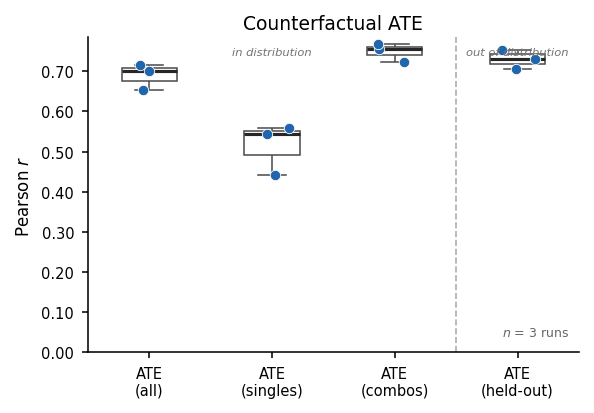

Panel A saved.


In [14]:
# ── Panel A: Counterfactual ATE — in-distribution and OOD ────────────────
METRIC_LABELS = {
    'ate_all':    'ATE\n(all)',
    'ate_single': 'ATE\n(singles)',
    'ate_combo':  'ATE\n(combos)',
    'ate_held':   'ATE\n(held-out)',
}

df_long = runs_df.melt(
    id_vars='run',
    value_vars=list(METRIC_LABELS),
    var_name='metric', value_name='Pearson r',
)
df_long['Metric'] = pd.Categorical(
    df_long['metric'].map(METRIC_LABELS),
    categories=[METRIC_LABELS[k] for k in METRIC_LABELS],
    ordered=True,
)

fig_a, ax_a = plt.subplots(figsize=(4.0, 2.8))

sns.stripplot(
    data=df_long, x='Metric', y='Pearson r',
    color=CLR_SHERLOCK, size=5, jitter=0.15,
    linewidth=0.4, edgecolor='white', ax=ax_a,
)
sns.boxplot(
    data=df_long, x='Metric', y='Pearson r',
    color='white', width=0.45, linewidth=0.75,
    fliersize=0, ax=ax_a,
    boxprops=dict(edgecolor='0.3'),
    whiskerprops=dict(color='0.3'),
    capprops=dict(color='0.3'),
    medianprops=dict(color='0.15', linewidth=1.5),
)

ax_a.axvline(2.5, color='0.55', linewidth=0.8, linestyle='--', alpha=0.7)
ax_a.set_ylim(bottom=0)
_ylim = ax_a.get_ylim()
_y_ann = _ylim[1] - 0.03 * (_ylim[1] - _ylim[0])
ax_a.text(1.0, _y_ann, 'in distribution', ha='center', va='top',
          fontsize=5.5, color='0.45', style='italic')
ax_a.text(3.0, _y_ann, 'out of distribution', ha='center', va='top',
          fontsize=5.5, color='0.45', style='italic')

ax_a.set_xlabel('')
ax_a.set_ylabel('Pearson $r$')
ax_a.set_title('Counterfactual ATE', pad=4)
ax_a.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_a.text(0.98, 0.04, f'$n$ = {N_RUNS} runs',
          transform=ax_a.transAxes, ha='right', va='bottom',
          fontsize=6, color='0.4')

plt.tight_layout()
fig_a.savefig(OUT_DIR / 'panel_a_ate.svg', bbox_inches='tight')
plt.show()
print('Panel A saved.')


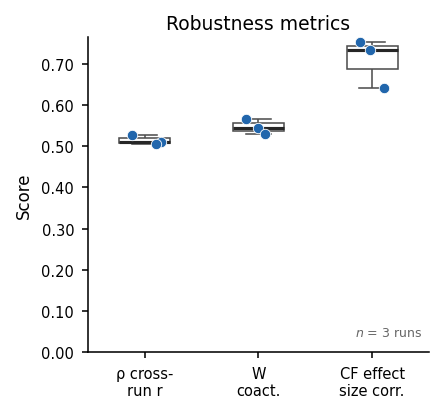

Panel B (robustness) saved.


In [15]:
# ── Panel B: Reproducibility / robustness metrics across N runs ───────────
ROBUST_LABELS = {
    'rho_cross_r':   'ρ cross-\nrun r',
    'w_coact':       'W\ncoact.',
    'effect_size_r': 'CF effect\nsize corr.',
}

df_robust = runs_df.melt(
    id_vars='run',
    value_vars=list(ROBUST_LABELS),
    var_name='metric', value_name='Score',
)
df_robust['Metric'] = pd.Categorical(
    df_robust['metric'].map(ROBUST_LABELS),
    categories=[ROBUST_LABELS[k] for k in ROBUST_LABELS],
    ordered=True,
)

fig_b2, ax_b2 = plt.subplots(figsize=(3.0, 2.8))

sns.stripplot(
    data=df_robust, x='Metric', y='Score',
    color=CLR_SHERLOCK, size=5, jitter=0.15,
    linewidth=0.4, edgecolor='white', ax=ax_b2,
)
sns.boxplot(
    data=df_robust, x='Metric', y='Score',
    color='white', width=0.45, linewidth=0.75,
    fliersize=0, ax=ax_b2,
    boxprops=dict(edgecolor='0.3'),
    whiskerprops=dict(color='0.3'),
    capprops=dict(color='0.3'),
    medianprops=dict(color='0.15', linewidth=1.5),
)

ax_b2.set_ylim(bottom=0)
ax_b2.set_xlabel('')
ax_b2.set_ylabel('Score')
ax_b2.set_title('Robustness metrics', pad=4)
ax_b2.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_b2.text(0.98, 0.04, f'$n$ = {N_RUNS} runs',
           transform=ax_b2.transAxes, ha='right', va='bottom',
           fontsize=6, color='0.4')

plt.tight_layout()
fig_b2.savefig(OUT_DIR / 'panel_b_robustness.svg', bbox_inches='tight')
plt.show()
print('Panel B (robustness) saved.')


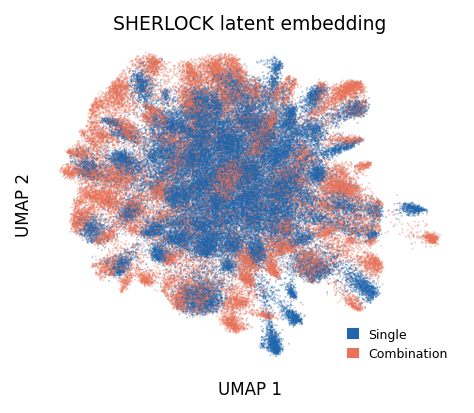

Panel C saved.


In [16]:
# ── Panel C: SHERLOCK latent embedding — singles vs combinations ──────────
_type_pal = {'single': CLR_SHERLOCK, 'combination': '#E8735A'}
_pt        = all_sub.obs['pert_type'].values

fig_c, ax_c = plt.subplots(figsize=(3.2, 2.8))
ax_c.scatter(
    all_sub.obsm['X_umap'][:, 0], all_sub.obsm['X_umap'][:, 1],
    c=[_type_pal[t] for t in _pt],
    s=0.8, alpha=0.4, linewidths=0, rasterized=True,
)
ax_c.set_xlabel('UMAP 1')
ax_c.set_ylabel('UMAP 2')
ax_c.set_title('SHERLOCK latent embedding', pad=4)
ax_c.set_xticks([])
ax_c.set_yticks([])
for sp in ax_c.spines.values():
    sp.set_visible(False)
ax_c.legend(
    handles=[Patch(color=v, label=k.capitalize()) for k, v in _type_pal.items()],
    fontsize=6, frameon=False, loc='lower right', handlelength=0.8,
)

plt.tight_layout()
fig_c.savefig(OUT_DIR / 'panel_c_umap.svg', bbox_inches='tight')
plt.show()
print('Panel C saved.')


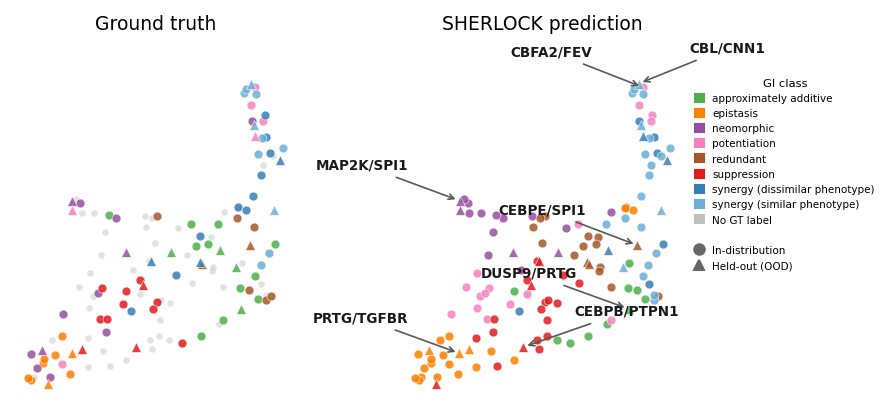

Panel D (synergy UMAP) saved.


In [17]:
# ── Panel D: Synergy UMAP — GT class (left) vs predicted class (right) ──
def _draw_synergy_umap(ax, umap_df, colour_col, title,
                       val_combos=None, arrow_pairs=None, show_unlabelled=False,
                       right_labels=None):
    """
    colour_col: column to colour by (gt_gi or predicted_gi).
    show_unlabelled: if True, draw NaN rows as gray (for GT panel only).
    arrow_pairs: {display_label: canonical_idx}
    """
    labelled   = umap_df[umap_df[colour_col].notna()].copy()
    unlabelled = umap_df[umap_df[colour_col].isna()].copy()

    if show_unlabelled and len(unlabelled) > 0:
        ax.scatter(
            unlabelled['UMAP1'], unlabelled['UMAP2'],
            color='0.75', s=10, alpha=0.45, linewidths=0, zorder=1,
        )

    if val_combos is not None:
        in_dist  = labelled[~labelled.index.isin(val_combos)]
        out_dist = labelled[labelled.index.isin(val_combos)]
    else:
        in_dist  = labelled
        out_dist = labelled.iloc[0:0]

    for cls in sorted(labelled[colour_col].unique()):
        color   = PALETTE_GI.get(str(cls), '#888888')
        grp_id  = in_dist[in_dist[colour_col] == cls]
        grp_ood = out_dist[out_dist[colour_col] == cls]
        if len(grp_id) > 0:
            ax.scatter(
                grp_id['UMAP1'], grp_id['UMAP2'],
                color=color, marker='o', s=18, alpha=0.85,
                linewidths=0.3, edgecolors='white', zorder=2,
            )
        if len(grp_ood) > 0:
            ax.scatter(
                grp_ood['UMAP1'], grp_ood['UMAP2'],
                color=color, marker='^', s=22, alpha=0.85,
                linewidths=0.3, edgecolors='white', zorder=3,
            )

    if arrow_pairs:
        for display_label, idx in arrow_pairs.items():
            if idx not in umap_df.index:
                continue
            row  = umap_df.loc[idx]
            x, y = float(row['UMAP1']), float(row['UMAP2'])
            _right = right_labels and display_label in right_labels
            ax.annotate(
                display_label,
                xy=(x, y), xytext=(x + 1.5 if _right else x - 1.5, y + 0.8),
                fontsize=6.5, fontweight='bold', color='0.1',
                ha='left' if _right else 'right', va='bottom',
                arrowprops=dict(
                    arrowstyle='->', color='0.35',
                    lw=0.8, shrinkA=2, shrinkB=2,
                ),
            )

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(title, pad=3, y=1.1)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)


fig_d, axes_d = plt.subplots(1, 2, figsize=(6.0, 2.8))

_draw_synergy_umap(axes_d[0], syn_umap, 'gt_gi', 'Ground truth',
                   val_combos=val_combos, arrow_pairs=None,
                   show_unlabelled=True)
_draw_synergy_umap(axes_d[1], syn_umap, 'predicted_gi', 'SHERLOCK prediction',
                   val_combos=val_combos, arrow_pairs=_gi_arrows,
                   show_unlabelled=False,
                   right_labels={'CBL/CNN1', 'CEBPB/PTPN1'})

# Legend
class_handles = [Patch(color=PALETTE_GI.get(cls, '#888888'), label=cls) for cls in sorted(PALETTE_GI)]
extra_handles = [
    Patch(color='0.75', label='No GT label'),
    Patch(color='none', label=''),
    Line2D([0], [0], marker='o', color='0.4', linestyle='None', ms=5, label='In-distribution'),
    Line2D([0], [0], marker='^', color='0.4', linestyle='None', ms=5, label='Held-out (OOD)'),
]
axes_d[1].legend(
    handles=class_handles + extra_handles,
    title='GI class', frameon=False,
    fontsize=5, title_fontsize=5.5,
    bbox_to_anchor=(1.01, 1), loc='upper left',
    handlelength=0.8, handleheight=0.8,
)

plt.tight_layout()
fig_d.savefig(OUT_DIR / 'panel_d_synergy_umap.svg', bbox_inches='tight')
plt.show()
print('Panel D (synergy UMAP) saved.')


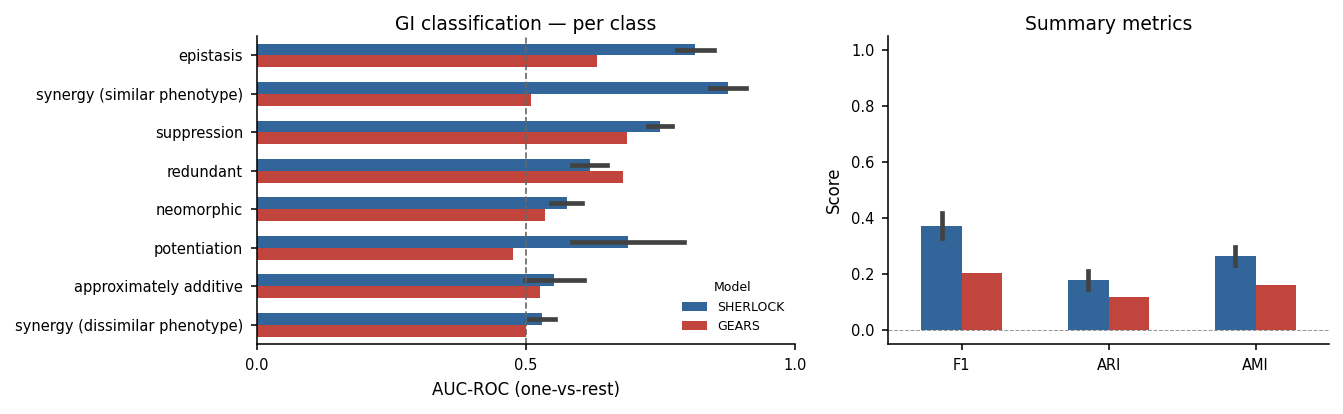

Panel E saved.


In [24]:
# ── Panel E: GI classification — per-class AUC (left) + summary (right) ──
class_order = (
    class_df.groupby('class')['auc_roc']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
bar_pal = {'SHERLOCK': CLR_SHERLOCK, 'GEARS': CLR_GEARS}

fig_e, (ax_e1, ax_e2) = plt.subplots(
    1, 2, figsize=(9.0, 2.8),
    gridspec_kw={'width_ratios': [2.2, 1.8]},
)

# Left: per-class AUC-ROC
sns.barplot(
    data=class_df_ci.dropna(subset=['auc_roc']),
    y='class', x='auc_roc',
    hue='model', hue_order=['SHERLOCK', 'GEARS'],
    palette=bar_pal, order=class_order,
    width=0.62, errorbar='sd', ax=ax_e1,
)
ax_e1.axvline(0.5, color='0.4', linewidth=0.8, linestyle='--')
ax_e1.set_xlabel('AUC-ROC (one-vs-rest)')
ax_e1.set_ylabel('')
ax_e1.set_title('GI classification — per class', pad=3)
ax_e1.set_xlim(0, 1)
ax_e1.set_xticks([0, 0.5, 1.0])
ax_e1.spines['top'].set_visible(False)
ax_e1.spines['right'].set_visible(False)
h1, l1 = ax_e1.get_legend_handles_labels()
ax_e1.legend(h1, l1, title='Model', frameon=False, fontsize=6, title_fontsize=6,
             loc='lower right')

# Right: F1, ARI, AMI with SHERLOCK CIs across runs
sns.barplot(
    data=summ_long_ci, x='Metric', y='score',
    hue='model', hue_order=['SHERLOCK', 'GEARS'],
    palette=bar_pal, width=0.55, errorbar='sd', ax=ax_e2,
)
ax_e2.axhline(0, color='0.6', linewidth=0.5, linestyle='--')
ax_e2.set_xlabel('')
ax_e2.set_ylabel('Score')
ax_e2.set_title('Summary metrics', pad=3)
ax_e2.set_ylim(-0.05, 1.05)
ax_e2.spines['top'].set_visible(False)
ax_e2.spines['right'].set_visible(False)
ax_e2.get_legend().remove()

plt.tight_layout()
fig_e.savefig(OUT_DIR / 'panel_e_gi_classification.svg', bbox_inches='tight')
plt.show()
print('Panel E saved.')


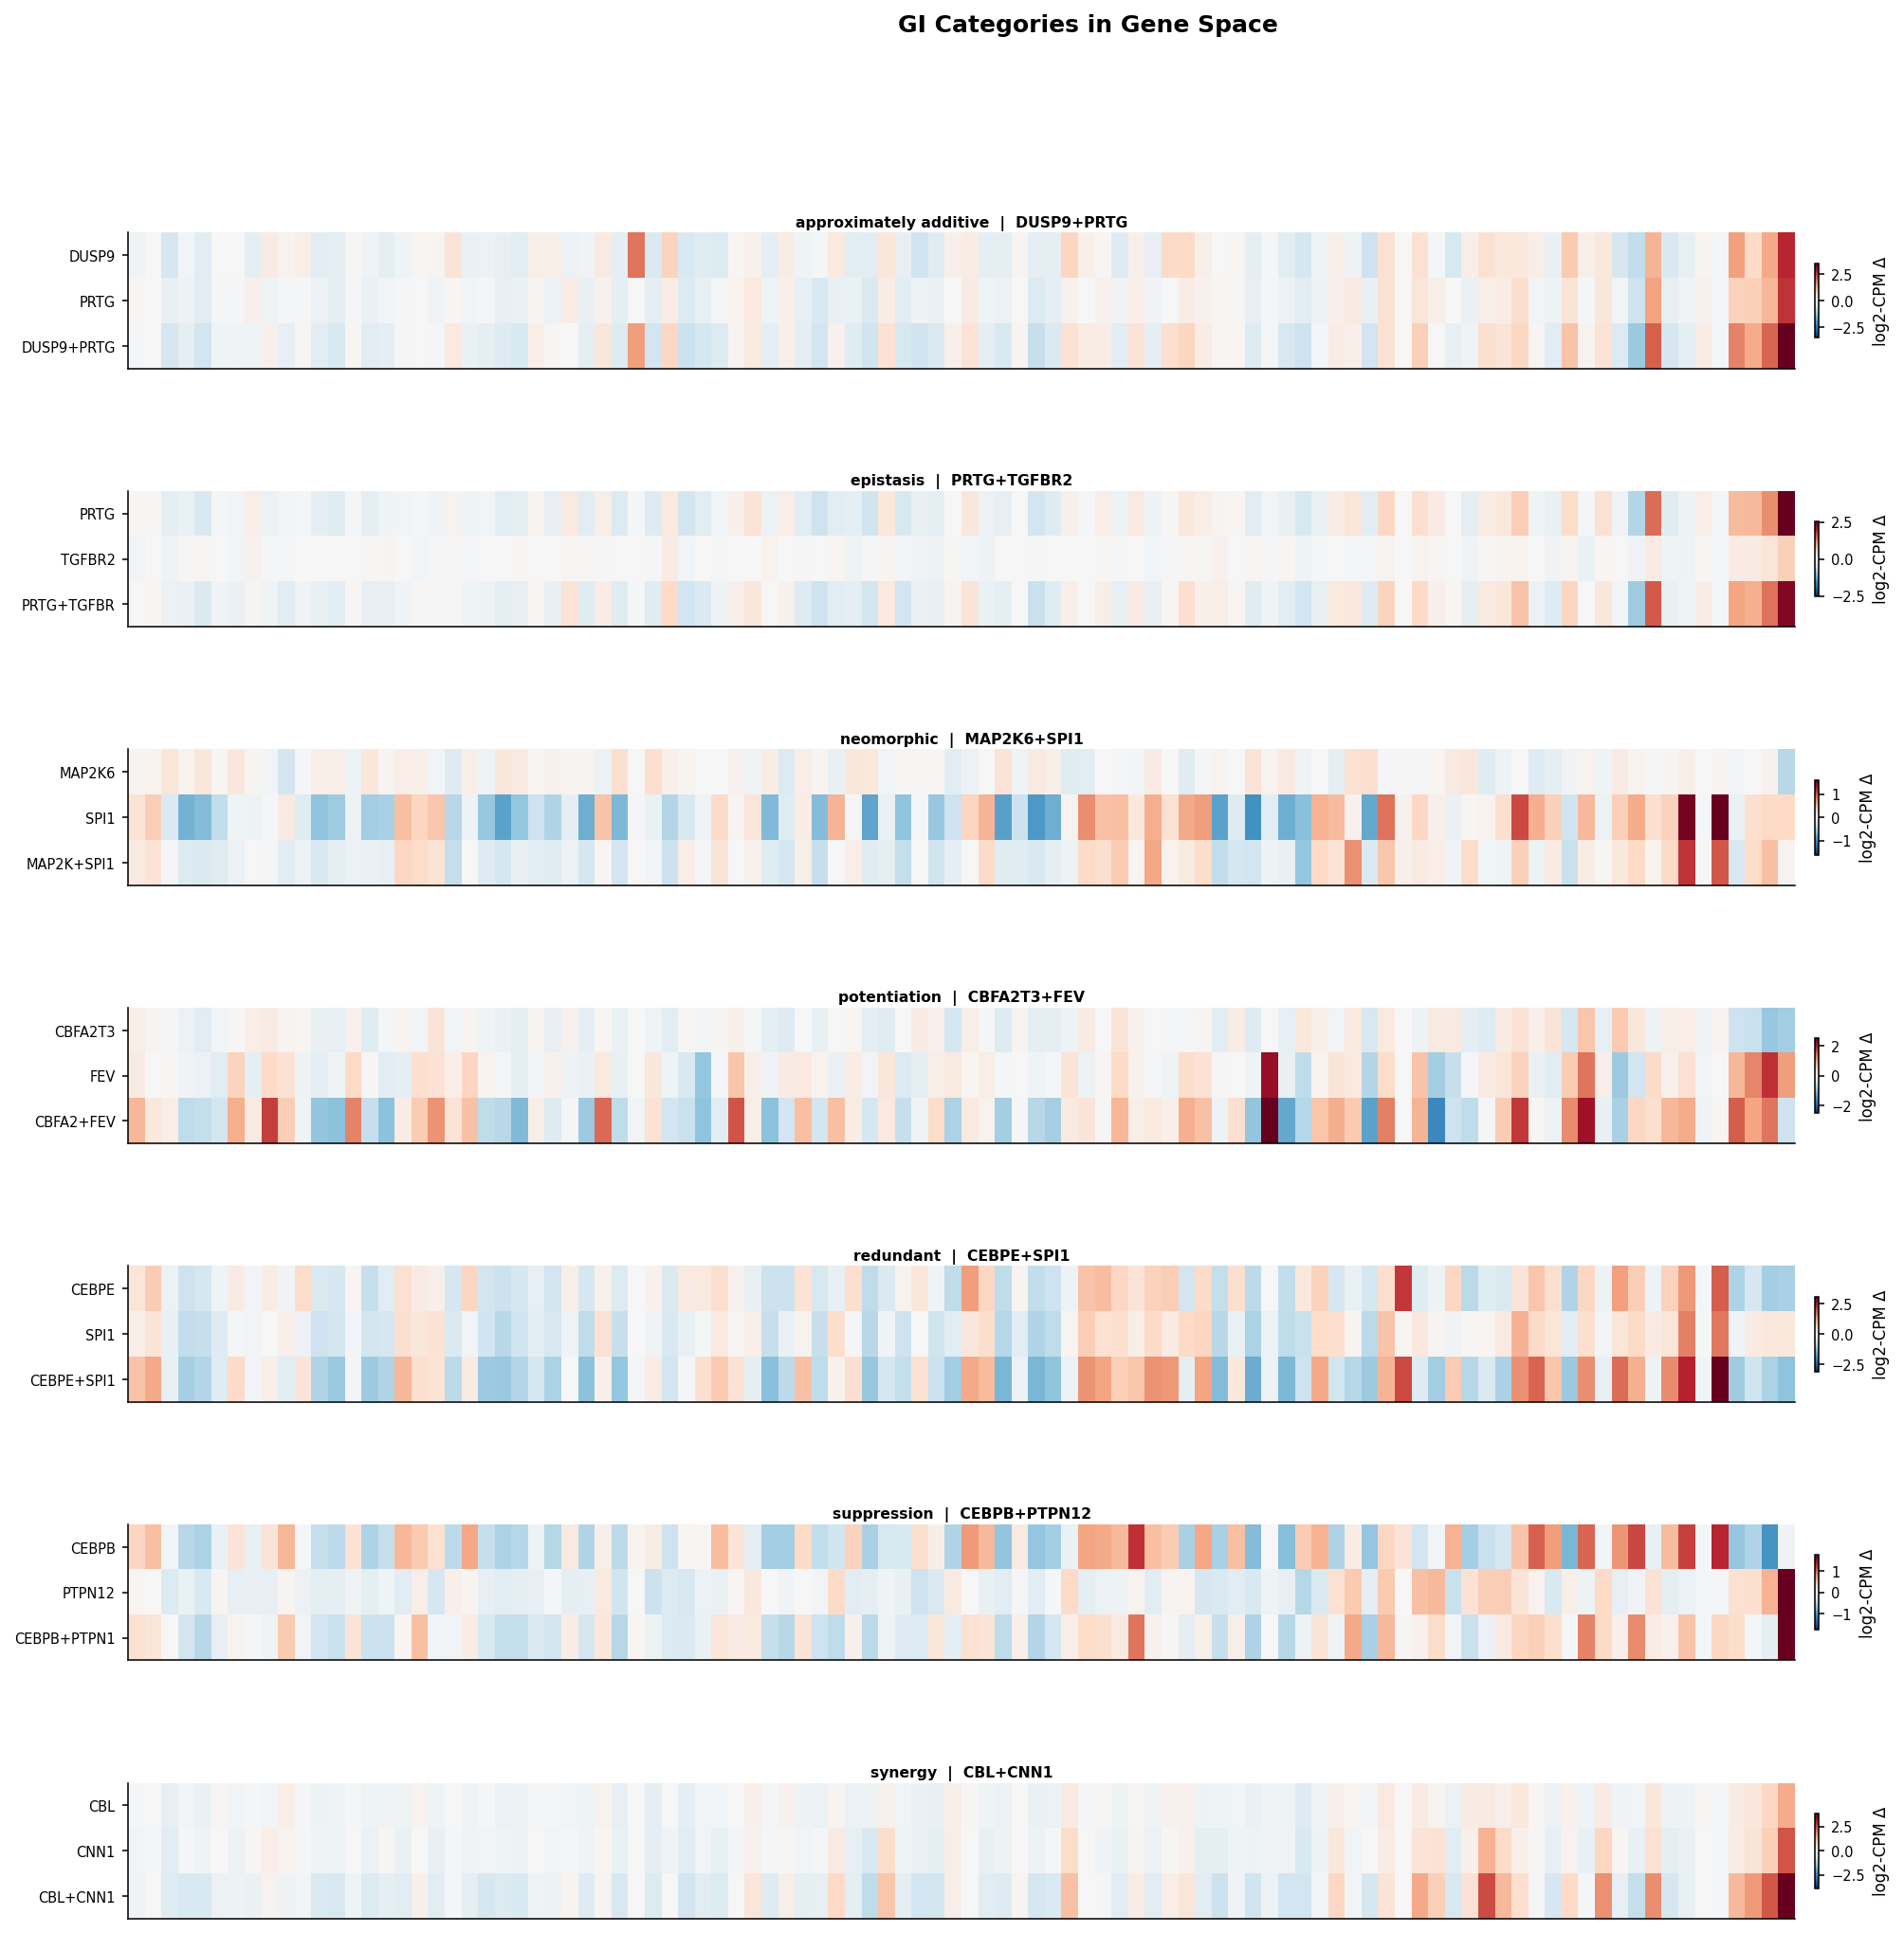

Panel F saved. Arrow pairs: ['CBL/CNN1', 'DUSP9/PRTG', 'PRTG/TGFBR', 'MAP2K/SPI1', 'CBFA2/FEV', 'CEBPE/SPI1', 'CEBPB/PTPN1']


In [23]:
# ── Panel F: GI Categories in Gene Space ─────────────────────────────────
# One correctly-classified example per GT category (prefer held-out).
# Gene pool: top 100 by variance across all perturbations in treat_effect.
# Also captures _gi_examples for use as panel D arrow annotations.

def _ch(s):
    parts = str(s).split('+', 1)
    return '+'.join(sorted(p.strip() for p in parts)) if len(parts) == 2 else str(s)

_te_f = data.uns['treat_effect'].to_df()
_te_f.index = _te_f.index.map(_ch)

def _eff_f(pert):
    k = _ch(pert)
    return _te_f.loc[k].values if k in _te_f.index else None

# Top-100 highest-variance genes across all perturbations
_hv100 = np.argsort(_te_f.var(axis=0).values)[-100:]

_cats_f = _cats_gi   # defined alongside _gi_examples in the synergy UMAP cell

_nf       = len(_gi_examples)
fig_f, _axes_f_col = plt.subplots(
    _nf, 1, figsize=(18, _nf * 2.2),
    gridspec_kw={'hspace': 0.9},
)
_axes_f_flat = np.array(_axes_f_col).flatten()

for _i, _cat in enumerate(_cats_f):
    _ax = _axes_f_flat[_i]
    if _cat not in _gi_examples:
        _ax.set_visible(False)
        continue

    _row        = _gi_examples[_cat]
    _na, _nb    = str(_row['pert_a']), str(_row['pert_b'])
    _combo      = _ch(f'{_na}+{_nb}')
    _A, _B, _AB = _eff_f(_na), _eff_f(_nb), _eff_f(_combo)

    if _A is None or _B is None or _AB is None:
        _ax.text(0.5, 0.5, f'missing data\n{_combo}', ha='center', va='center',
                 transform=_ax.transAxes, fontsize=7)
        continue

    _mat  = np.stack([_A[_hv100], _B[_hv100], _AB[_hv100]])
    _vabs = float(np.abs(_mat).max()) or 1.0
    _im   = _ax.imshow(_mat, aspect='auto', cmap='RdBu_r',
                       vmin=-_vabs, vmax=_vabs, interpolation='nearest')
    plt.colorbar(_im, ax=_ax, shrink=0.55, pad=0.01, label='log2-CPM Δ')

    _ax.set_yticks([0, 1, 2])
    _ax.set_yticklabels([_na, _nb, f'{_na[:5]}+{_nb[:5]}'], fontsize=7)
    _ax.set_xticks([])
    _ax.set_title(f'{_cat}  |  {_combo}', fontsize=7.5, fontweight='bold', pad=3)



fig_f.suptitle('GI Categories in Gene Space', fontsize=12, fontweight='bold')
fig_f.savefig(OUT_DIR / 'panel_f_gi_heatmap.svg', bbox_inches='tight')
plt.show()

# Build arrow dict for panel D
_gi_arrows = {}
for _cat, _row in _gi_examples.items():
    _na2, _nb2 = str(_row['pert_a']), str(_row['pert_b'])
    _cidx = _ch(f'{_na2}+{_nb2}')
    if _cidx in syn_umap.index:
        _lbl = f'{_na2[:5]}/{_nb2[:5]}'
        _gi_arrows[_lbl] = _cidx

print(f'Panel F saved. Arrow pairs: {list(_gi_arrows.keys())}')


Main figure saved to results/norman_figure/main_figure.svg


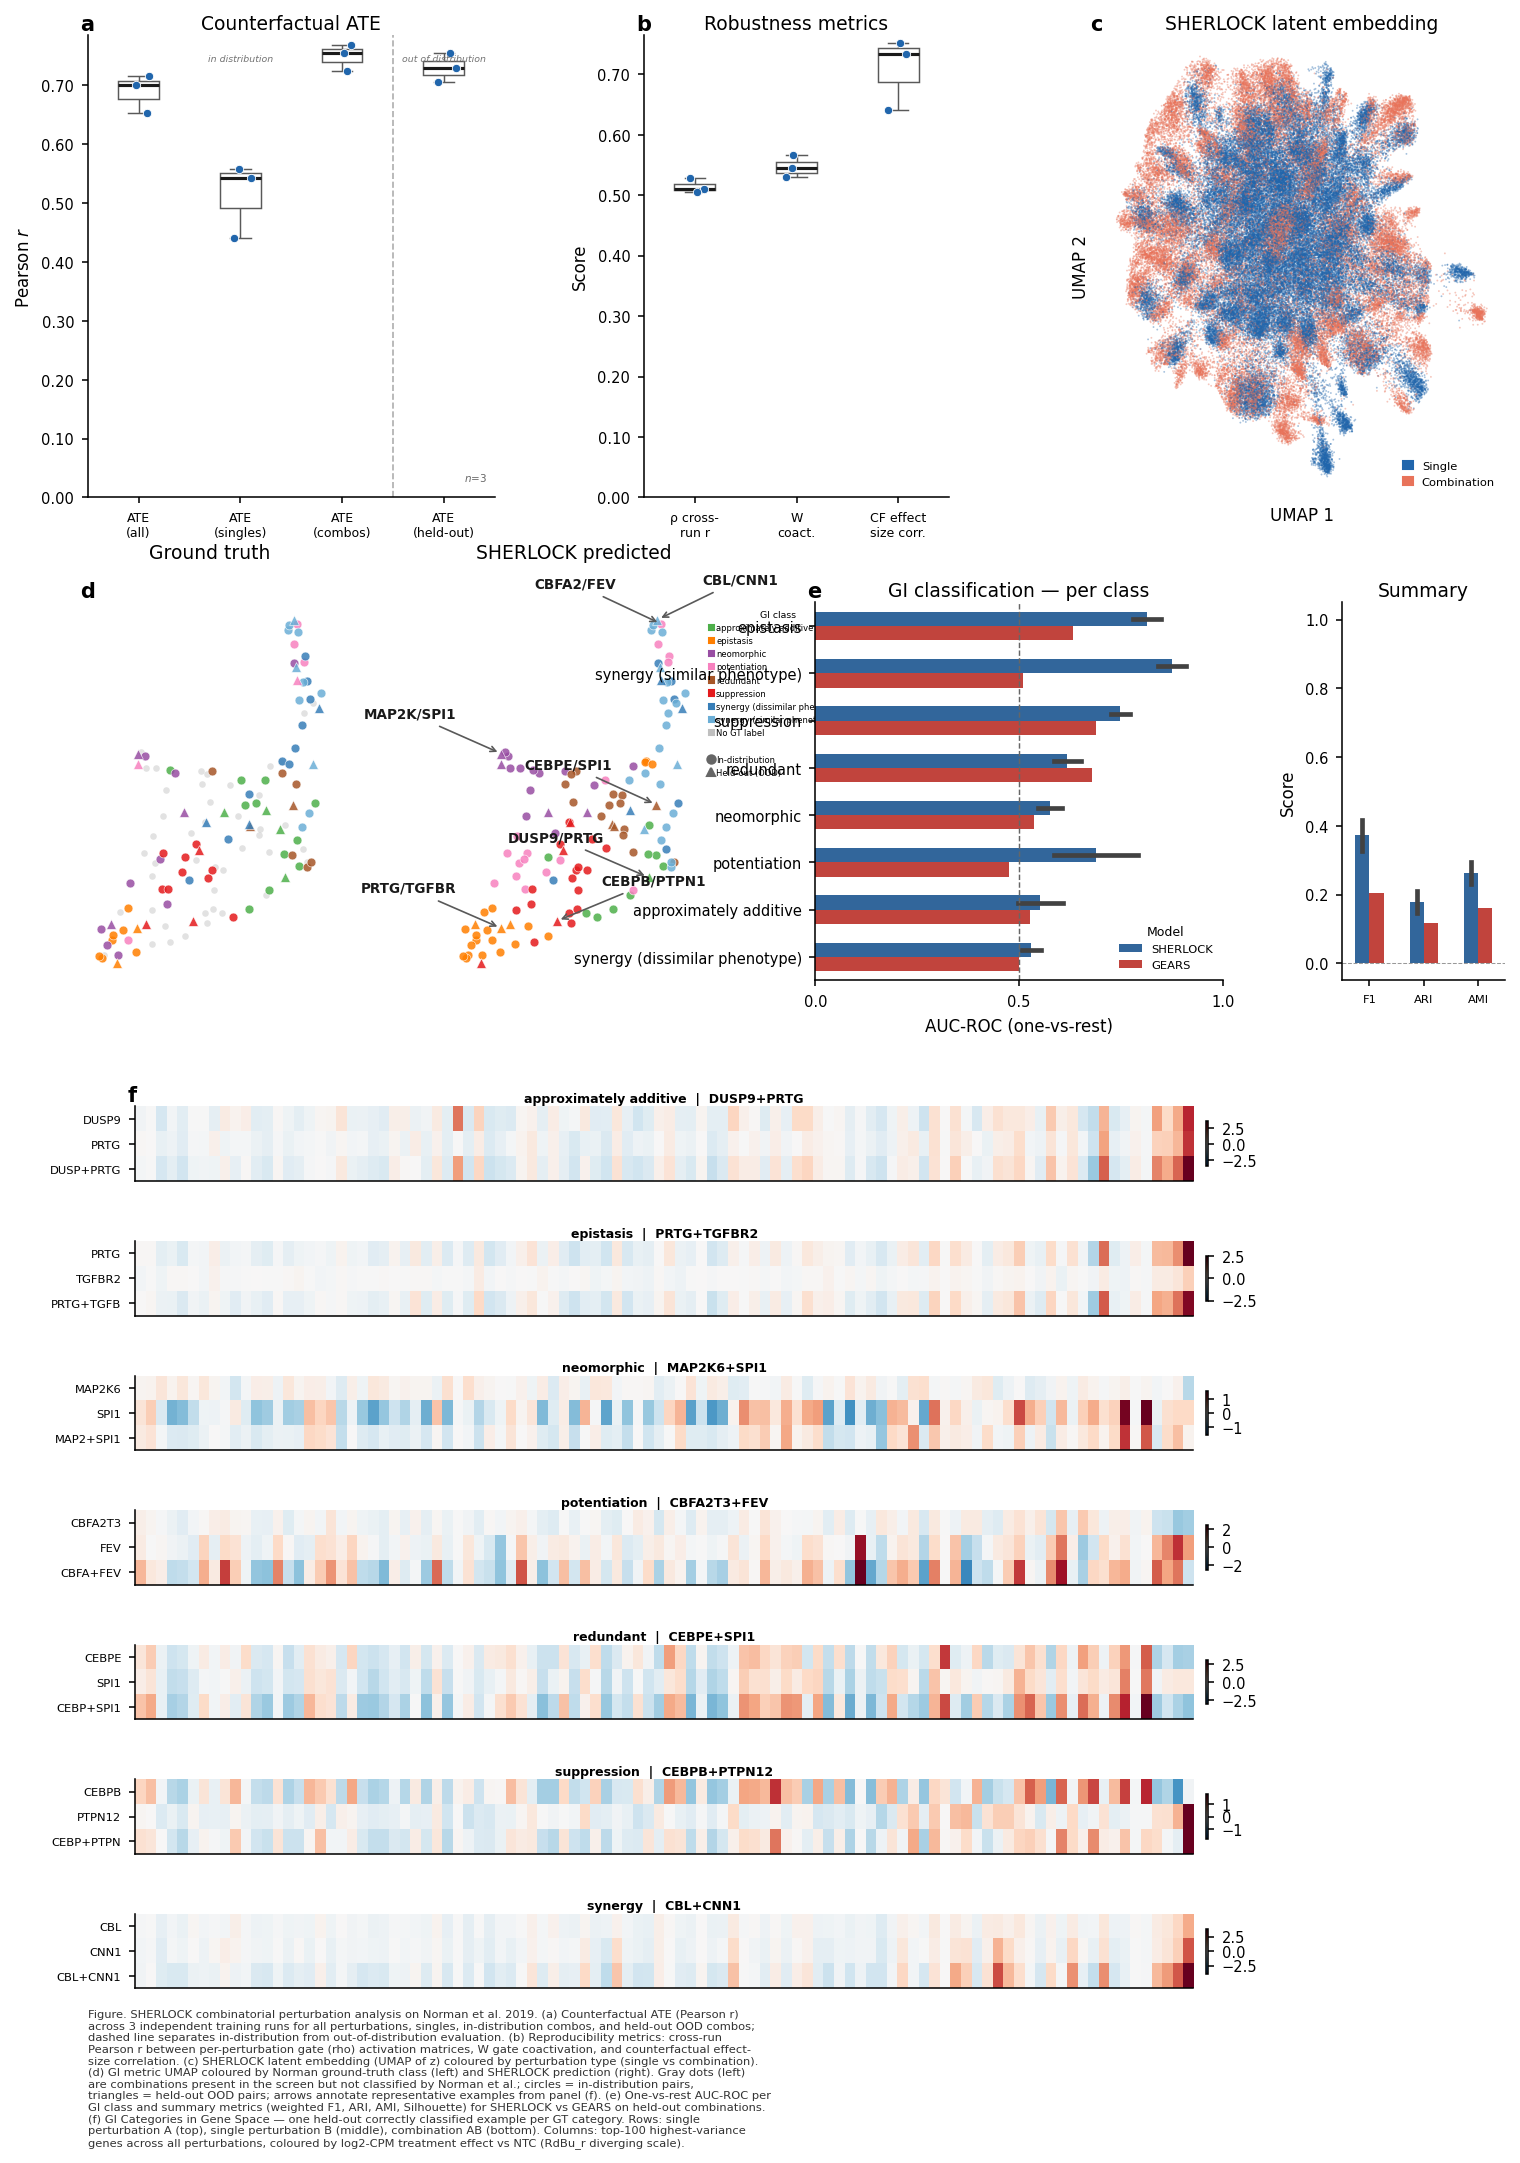

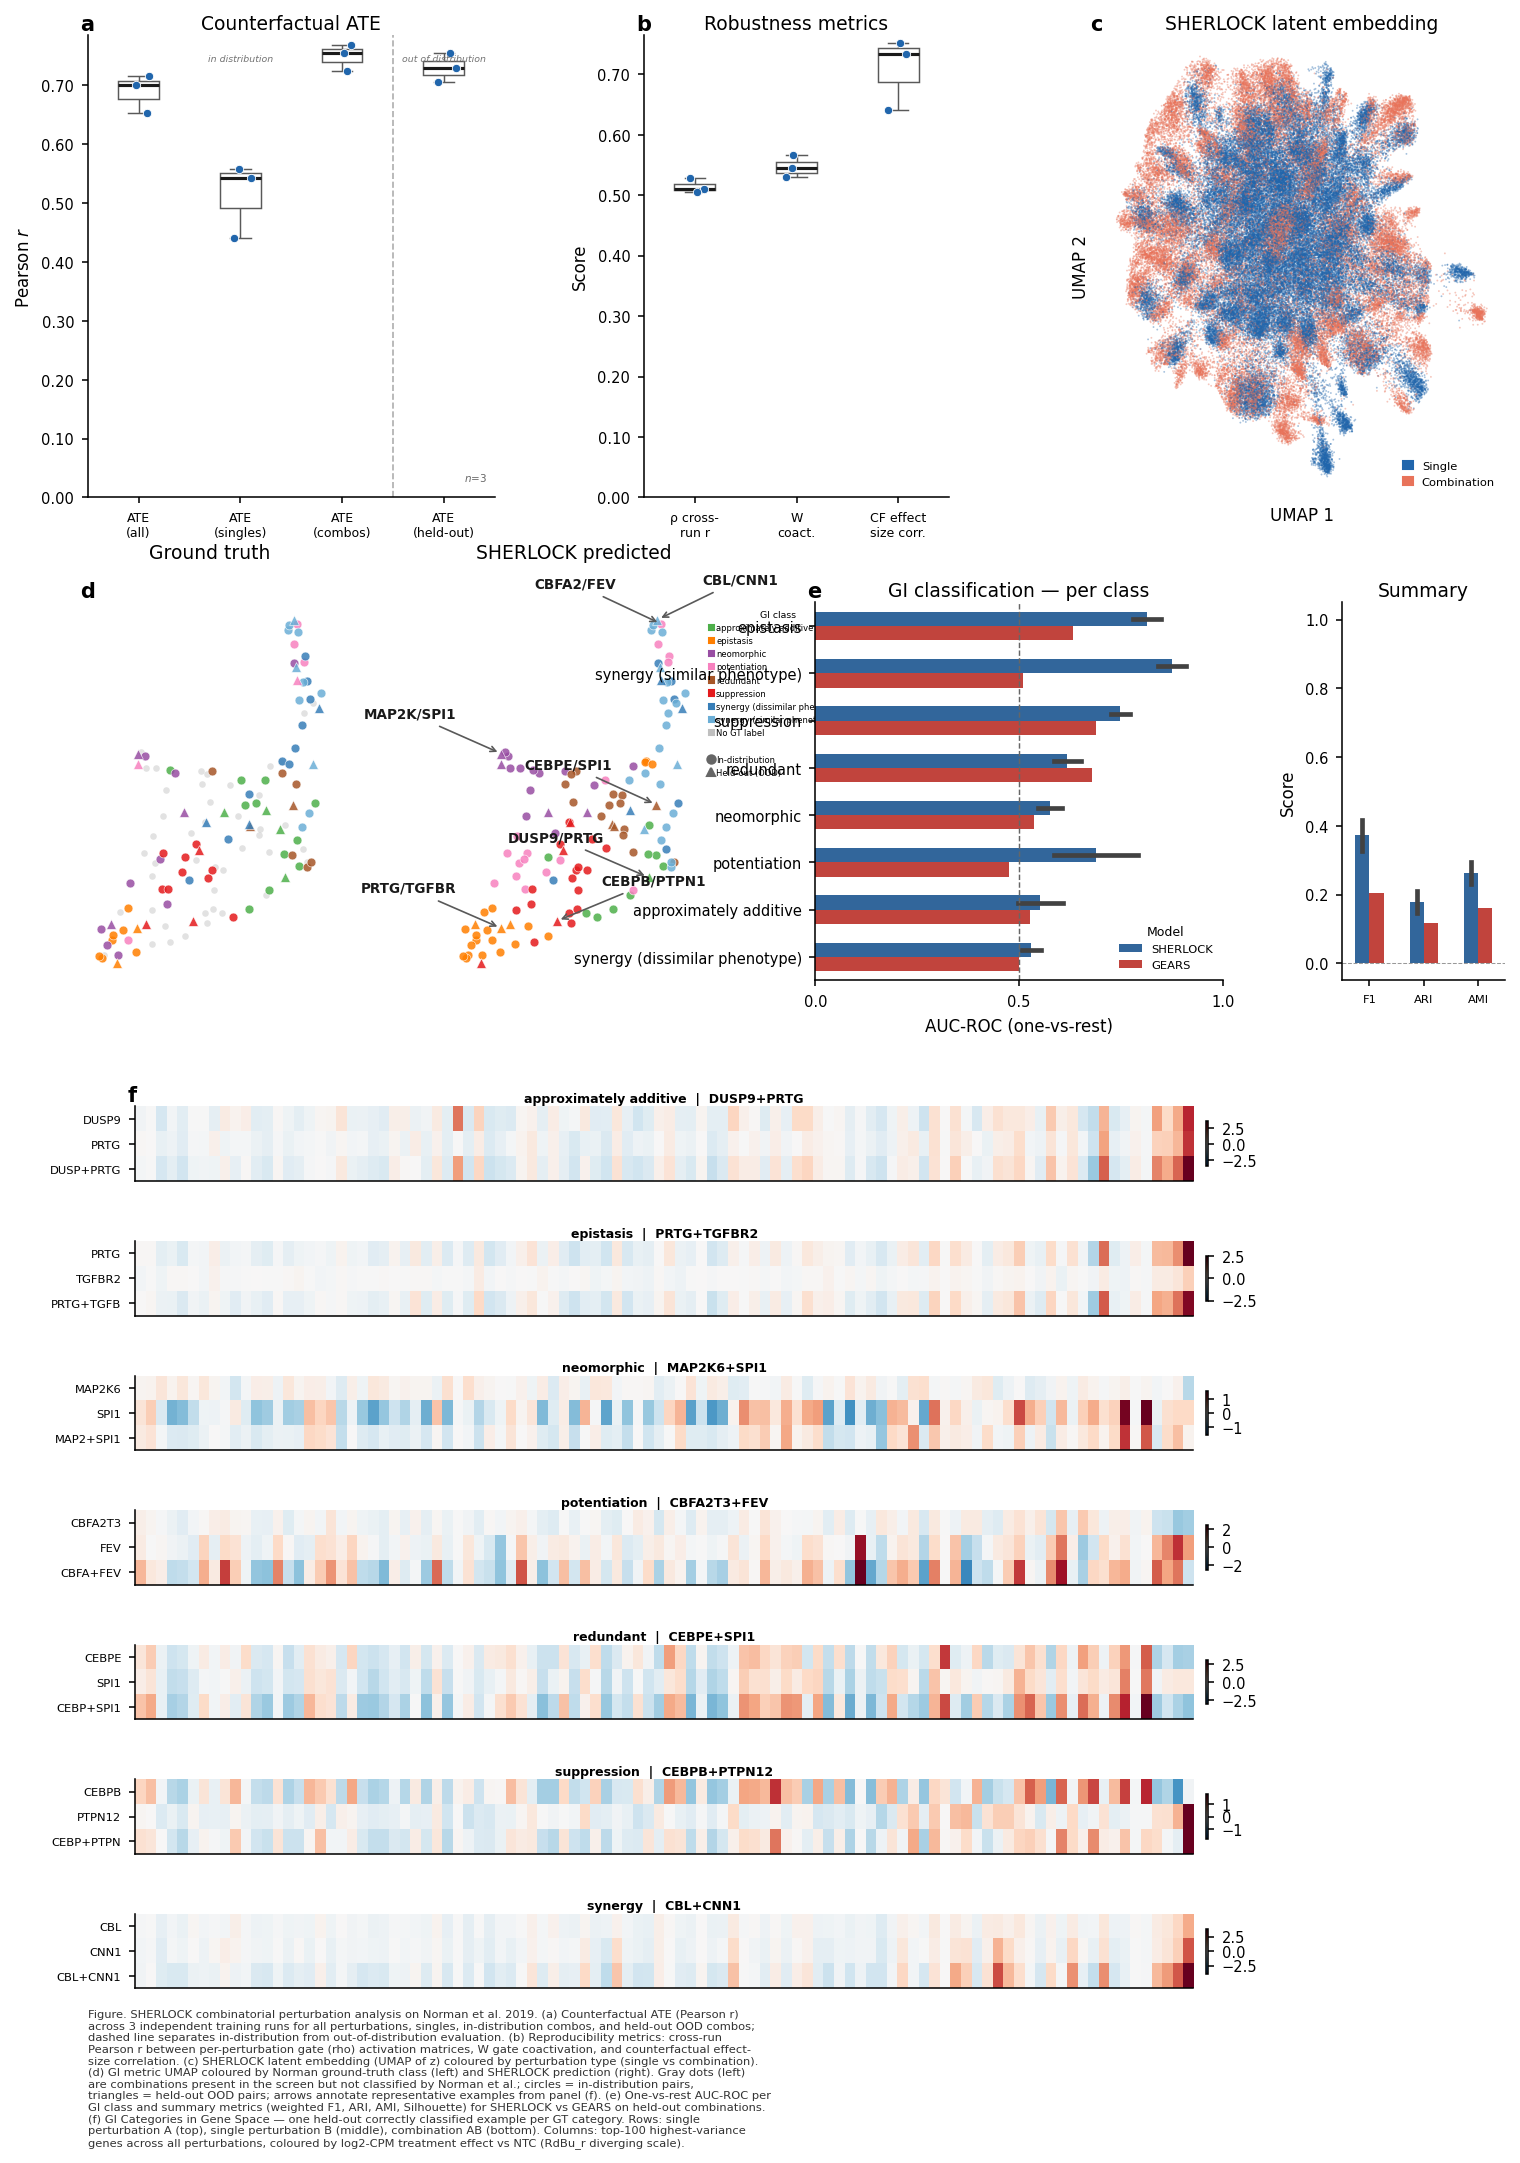

In [20]:
# ── Composite main figure — 6 panels ─────────────────────────────────────
FIG_W, FIG_H = 10.5, 14.0
LABEL_KW = dict(fontsize=10, fontweight='bold', va='top', ha='left')

plt.close('all')
fig = plt.figure(figsize=(FIG_W, FIG_H))

gs_top = fig.add_gridspec(
    1, 3, width_ratios=[4, 3, 4],
    left=0.07, right=0.97, top=0.97, bottom=0.75,
    wspace=0.40,
)
gs_mid = fig.add_gridspec(
    1, 4, width_ratios=[3, 3, 5, 2],
    left=0.07, right=0.97, top=0.70, bottom=0.52,
    wspace=0.45,
)
gs_bot = fig.add_gridspec(
    7, 1,
    left=0.10, right=0.90, top=0.46, bottom=0.04,
    hspace=0.80,
)

ax_a    = fig.add_subplot(gs_top[0, 0])
ax_b    = fig.add_subplot(gs_top[0, 1])
ax_c    = fig.add_subplot(gs_top[0, 2])
ax_d_gt = fig.add_subplot(gs_mid[0, 0])
ax_d_pd = fig.add_subplot(gs_mid[0, 1])
ax_e1   = fig.add_subplot(gs_mid[0, 2])
ax_e2   = fig.add_subplot(gs_mid[0, 3])
_axes_f = [fig.add_subplot(gs_bot[r, 0]) for r in range(7)]

# ── (a) Counterfactual ATE ────────────────────────────────────────────────
sns.stripplot(data=df_long, x='Metric', y='Pearson r',
    color=CLR_SHERLOCK, size=4, jitter=0.12,
    linewidth=0.4, edgecolor='white', ax=ax_a)
sns.boxplot(data=df_long, x='Metric', y='Pearson r',
    color='white', width=0.40, linewidth=0.7, fliersize=0, ax=ax_a,
    boxprops=dict(edgecolor='0.35'), whiskerprops=dict(color='0.35'),
    capprops=dict(color='0.35'), medianprops=dict(color='0.1', linewidth=1.5))
ax_a.axvline(2.5, color='0.55', linewidth=0.8, linestyle='--', alpha=0.7)
ax_a.set_ylim(bottom=0)
_yl = ax_a.get_ylim()
_ya = _yl[1] - 0.04 * (_yl[1] - _yl[0])
ax_a.text(1.0, _ya, 'in distribution', ha='center', va='top',
    fontsize=4.5, color='0.45', style='italic')
ax_a.text(3.0, _ya, 'out of distribution', ha='center', va='top',
    fontsize=4.5, color='0.45', style='italic')
ax_a.set_xlabel(''); ax_a.set_ylabel('Pearson $r$')
ax_a.set_title('Counterfactual ATE', pad=3)
ax_a.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_a.tick_params(axis='x', labelsize=6)
ax_a.text(0.98, 0.03, f'$n$={N_RUNS}',
    transform=ax_a.transAxes, ha='right', va='bottom', fontsize=5, color='0.4')
ax_a.spines['top'].set_visible(False); ax_a.spines['right'].set_visible(False)

# ── (b) Robustness metrics ────────────────────────────────────────────────
sns.stripplot(data=df_robust, x='Metric', y='Score',
    color=CLR_SHERLOCK, size=4, jitter=0.12,
    linewidth=0.4, edgecolor='white', ax=ax_b)
sns.boxplot(data=df_robust, x='Metric', y='Score',
    color='white', width=0.40, linewidth=0.7, fliersize=0, ax=ax_b,
    boxprops=dict(edgecolor='0.35'), whiskerprops=dict(color='0.35'),
    capprops=dict(color='0.35'), medianprops=dict(color='0.1', linewidth=1.5))
ax_b.set_ylim(bottom=0)
ax_b.set_xlabel(''); ax_b.set_ylabel('Score')
ax_b.set_title('Robustness metrics', pad=3)
ax_b.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_b.tick_params(axis='x', labelsize=6)
ax_b.spines['top'].set_visible(False); ax_b.spines['right'].set_visible(False)

# ── (c) SHERLOCK latent embedding — singles & combos ─────────────────────
_type_pal  = {'single': CLR_SHERLOCK, 'combination': '#E8735A'}
_pt        = all_sub.obs['pert_type'].values
ax_c.scatter(
    all_sub.obsm['X_umap'][:, 0], all_sub.obsm['X_umap'][:, 1],
    c=[_type_pal[t] for t in _pt],
    s=0.8, alpha=0.4, linewidths=0, rasterized=True,
)
ax_c.set_xlabel('UMAP 1'); ax_c.set_ylabel('UMAP 2')
ax_c.set_title('SHERLOCK latent embedding', pad=3)
ax_c.set_xticks([]); ax_c.set_yticks([])
for sp in ax_c.spines.values(): sp.set_visible(False)
ax_c.legend(
    handles=[Patch(color=v, label=k.capitalize()) for k, v in _type_pal.items()],
    fontsize=5.5, frameon=False, loc='lower right', handlelength=0.8,
)

# ── (d) Synergy UMAPs ─────────────────────────────────────────────────────
_draw_synergy_umap(ax_d_gt, syn_umap, 'gt_gi', 'Ground truth',
                   val_combos=val_combos, arrow_pairs=None,
                   show_unlabelled=True)
_draw_synergy_umap(ax_d_pd, syn_umap, 'predicted_gi', 'SHERLOCK predicted',
                   val_combos=val_combos, arrow_pairs=_gi_arrows,
                   show_unlabelled=False,
                   right_labels={'CBL/CNN1', 'CEBPB/PTPN1'})

gi_handles = [Patch(color=PALETTE_GI.get(cls, '#888888'), label=cls) for cls in sorted(PALETTE_GI)]
extra_handles = [
    Patch(color='0.75', label='No GT label'),
    Patch(color='none', label=''),
    Line2D([0], [0], marker='o', color='0.4', linestyle='None', ms=4, label='In-distribution'),
    Line2D([0], [0], marker='^', color='0.4', linestyle='None', ms=4, label='Held-out (OOD)'),
]
ax_d_pd.legend(
    handles=gi_handles + extra_handles,
    title='GI class', frameon=False,
    fontsize=4, title_fontsize=4.5,
    bbox_to_anchor=(1.02, 1), loc='upper left',
    handlelength=0.6, handleheight=0.6, handletextpad=0.3,
)

# ── (e-left) Per-class AUC-ROC ────────────────────────────────────────────
sns.barplot(data=class_df_ci.dropna(subset=['auc_roc']),
    y='class', x='auc_roc',
    hue='model', hue_order=['SHERLOCK', 'GEARS'],
    palette=bar_pal, order=class_order, width=0.60, errorbar='sd', ax=ax_e1)
ax_e1.axvline(0.5, color='0.4', linewidth=0.7, linestyle='--')
ax_e1.set_xlabel('AUC-ROC (one-vs-rest)'); ax_e1.set_ylabel('')
ax_e1.set_title('GI classification — per class', pad=3)
ax_e1.set_xlim(0, 1); ax_e1.set_xticks([0, 0.5, 1.0])
ax_e1.spines['top'].set_visible(False); ax_e1.spines['right'].set_visible(False)
h1, l1 = ax_e1.get_legend_handles_labels()
ax_e1.legend(h1, l1, title='Model', frameon=False,
    fontsize=5.5, title_fontsize=6, loc='lower right')

# ── (e-right) Summary metrics ─────────────────────────────────────────────
sns.barplot(data=summ_long_ci, x='Metric', y='score',
    hue='model', hue_order=['SHERLOCK', 'GEARS'],
    palette=bar_pal, width=0.52, errorbar='sd', ax=ax_e2)
ax_e2.axhline(0, color='0.6', linewidth=0.5, linestyle='--')
ax_e2.set_xlabel(''); ax_e2.set_ylabel('Score')
ax_e2.set_title('Summary', pad=3)
ax_e2.set_ylim(-0.05, 1.05)
ax_e2.spines['top'].set_visible(False); ax_e2.spines['right'].set_visible(False)
ax_e2.tick_params(axis='x', labelsize=5.5)
ax_e2.get_legend().remove()

# ── (f) GI Categories in Gene Space ──────────────────────────────────────
for _i, _cat in enumerate(_cats_f):
    _ax = _axes_f[_i]
    if _cat not in _gi_examples:
        _ax.set_visible(False)
        continue

    _row        = _gi_examples[_cat]
    _na, _nb    = str(_row['pert_a']), str(_row['pert_b'])
    _combo      = _ch(f'{_na}+{_nb}')
    _A, _B, _AB = _eff_f(_na), _eff_f(_nb), _eff_f(_combo)

    if _A is None or _B is None or _AB is None:
        _ax.text(0.5, 0.5, f'missing\n{_combo}', ha='center', va='center',
                 transform=_ax.transAxes, fontsize=6)
        continue

    _mat  = np.stack([_A[_hv100], _B[_hv100], _AB[_hv100]])
    _vabs = float(np.abs(_mat).max()) or 1.0
    _im   = _ax.imshow(_mat, aspect='auto', cmap='RdBu_r',
                       vmin=-_vabs, vmax=_vabs, interpolation='nearest',
                       rasterized=True)
    plt.colorbar(_im, ax=_ax, shrink=0.6, pad=0.01)

    _ax.set_yticks([0, 1, 2])
    _ax.set_yticklabels([_na, _nb, f'{_na[:4]}+{_nb[:4]}'], fontsize=5.5)
    _ax.set_xticks([])
    _ax.set_title(f'{_cat}  |  {_combo}', fontsize=6, fontweight='bold', pad=2)


# ── Subfigure labels ──────────────────────────────────────────────────────
def _pos(gs_obj, row, col):
    bbox = gs_obj[row, col].get_position(fig)
    return bbox.x0 - 0.005, bbox.y1 + 0.010

for lbl, (x, y) in {
    'a': _pos(gs_top, 0, 0),
    'b': _pos(gs_top, 0, 1),
    'c': _pos(gs_top, 0, 2),
    'd': _pos(gs_mid, 0, 0),
    'e': _pos(gs_mid, 0, 2),
    'f': _pos(gs_bot, 0, 0),
}.items():
    fig.text(x, y, lbl, **LABEL_KW)

# ── Figure caption ────────────────────────────────────────────────────────
_caption_raw = (
    "Figure. SHERLOCK combinatorial perturbation analysis on Norman et al. 2019. "
    "(a) Counterfactual ATE (Pearson r) across {n} independent training runs for all "
    "perturbations, singles, in-distribution combos, and held-out OOD combos; dashed line "
    "separates in-distribution from out-of-distribution evaluation. "
    "(b) Reproducibility metrics: cross-run Pearson r between per-perturbation gate (rho) "
    "activation matrices, W gate coactivation, and counterfactual effect-size correlation. "
    "(c) SHERLOCK latent embedding (UMAP of z) coloured by perturbation type "
    "(single vs combination). "
    "(d) GI metric UMAP coloured by Norman ground-truth class (left) and SHERLOCK prediction "
    "(right). Gray dots (left) are combinations present in the screen but not classified by "
    "Norman et al.; circles = in-distribution pairs, triangles = held-out OOD pairs; "
    "arrows annotate representative examples from panel (f). "
    "(e) One-vs-rest AUC-ROC per GI class and summary metrics "
    "(weighted F1, ARI, AMI, Silhouette) for SHERLOCK vs GEARS on held-out combinations. "
    "(f) GI Categories in Gene Space — one held-out correctly classified example per GT category. "
    "Rows: single perturbation A (top), single perturbation B (middle), combination AB (bottom). "
    "Columns: top-100 highest-variance genes across all perturbations, coloured by "
    "log2-CPM treatment effect vs NTC (RdBu_r diverging scale)."
).format(n=N_RUNS)

fig.text(
    0.07, 0.03,
    textwrap.fill(_caption_raw, width=115),
    ha='left', va='top', fontsize=5.5, color='0.2',
    transform=fig.transFigure,
)

fig.savefig(OUT_DIR / 'main_figure.svg', bbox_inches='tight')
print(f'Main figure saved to {OUT_DIR}/main_figure.svg')
fig


In [21]:
# ── Summary statistics ────────────────────────────────────────────────────
print('=== ATE across runs ===')
print(runs_df[['run', 'ate_all', 'ate_single', 'ate_combo', 'ate_held']].to_string(index=False))

print(f'\nMean ± SD:')
for col in ['ate_all', 'ate_single', 'ate_combo', 'ate_held']:
    print(f"  {col:15s}  {runs_df[col].mean():.4f} ± {runs_df[col].std():.4f}")

print('\n=== GI classification summary (SHERLOCK vs GEARS) ===')
print(summary_df[['model', 'f1_weighted', 'silhouette', 'ari', 'ami']].to_string(index=False))

=== ATE across runs ===
 run  ate_all  ate_single  ate_combo  ate_held
   1 0.700263    0.543195   0.755333  0.730099
   2 0.653907    0.441180   0.724353  0.704992
   3 0.715951    0.558548   0.768442  0.754409

Mean ± SD:
  ate_all          0.6900 ± 0.0323
  ate_single       0.5143 ± 0.0638
  ate_combo        0.7494 ± 0.0226
  ate_held         0.7298 ± 0.0247

=== GI classification summary (SHERLOCK vs GEARS) ===
   model  f1_weighted  silhouette      ari      ami
SHERLOCK     0.487783   -0.016361 0.219913 0.308541
   GEARS     0.205186   -0.114526 0.117325 0.159543


Overall silhouette: 0.0054
GT samples used: 86 in 8 classes

                                  mean   n    std
class                                            
potentiation                   -0.4090   6 0.1910
neomorphic                     -0.2475  12 0.2155
synergy (dissimilar phenotype) -0.0795  13 0.1404
redundant                      -0.0412   8 0.1504
approximately additive          0.0420  15 0.0980
synergy (similar phenotype)     0.1276  11 0.2368
epistasis                       0.1688   9 0.1380
suppression                     0.3079  12 0.1163


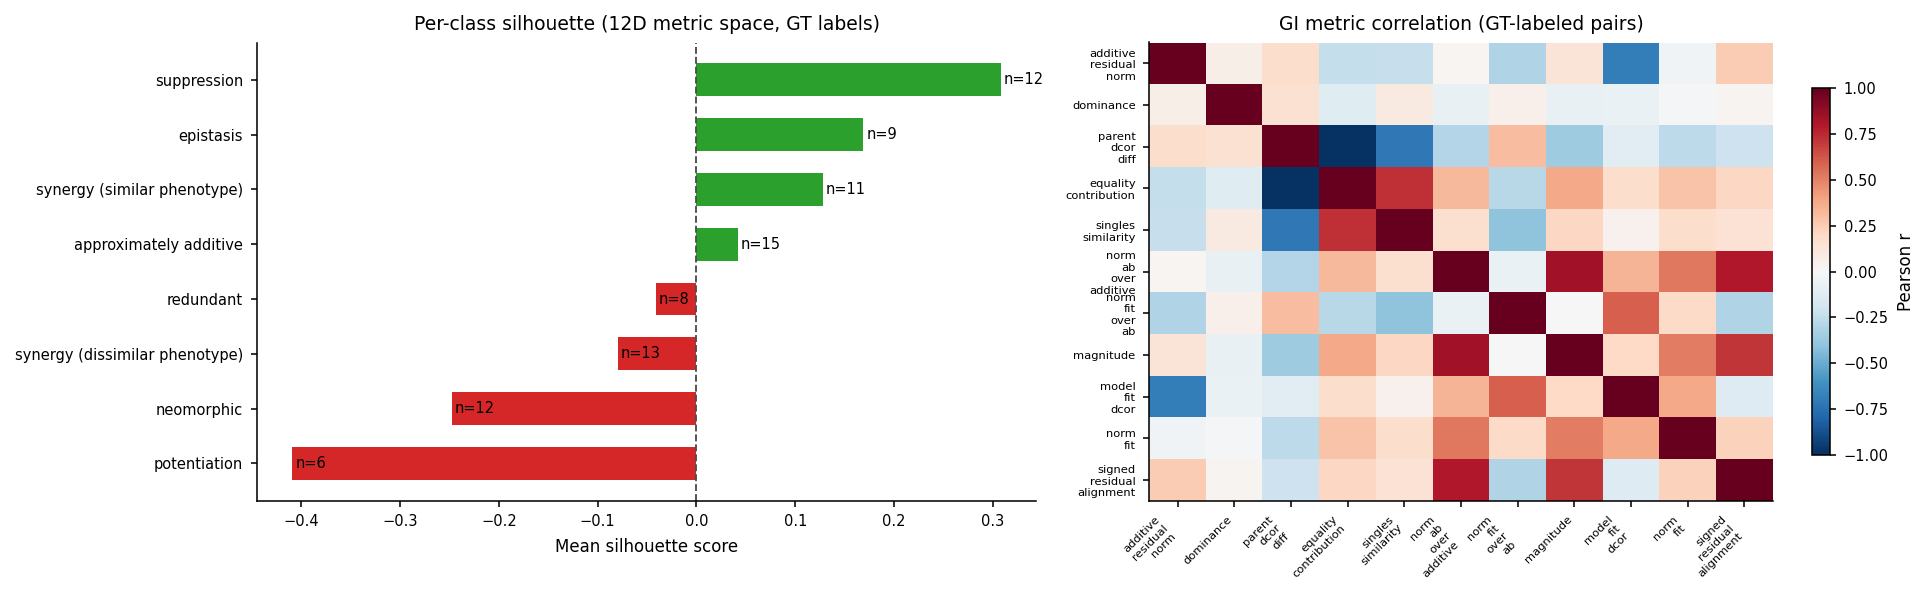

In [22]:
# ── Silhouette investigation ──────────────────────────────────────────────
# Silhouette is computed in the 12D GI metric space (StandardScaled).
# Low overall score can stem from: (1) overlapping classes in metric space,
# (2) small classes making estimation unreliable, (3) correlated metrics
# reducing effective dimensionality without removing redundancy.

from sklearn.metrics import silhouette_samples

# Replicate the _cluster_metrics computation for SHERLOCK
_both  = syn_umap[syn_umap['gt_gi'].notna()].copy()
_avail = [c for c in GI_METRICS if c in _both.columns]
_X_raw = _both[_avail].values.astype(float)
_fin   = np.all(np.isfinite(_X_raw), axis=1)
_both  = _both[_fin].copy()
_X_s   = StandardScaler().fit_transform(_X_raw[_fin])
_y_gt  = _both['gt_gi'].values.astype(str)

# Per-sample silhouette → aggregate per class
_samp_sil = silhouette_samples(_X_s, _y_gt)
_sil_df   = pd.DataFrame({'class': _y_gt, 'silhouette': _samp_sil})
_per_cls  = (_sil_df.groupby('class')['silhouette']
               .agg(mean='mean', n='count', std='std')
               .sort_values('mean'))

print(f"Overall silhouette: {_samp_sil.mean():.4f}")
print(f"GT samples used: {len(_y_gt)} in {len(np.unique(_y_gt))} classes\n")
print(_per_cls.to_string(float_format='{:.4f}'.format))

# Metric pairwise correlation (may reveal redundancy inflating some distances)
_corr = pd.DataFrame(_X_raw[_fin], columns=_avail).corr()

fig_inv, (ax_i1, ax_i2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: per-class mean silhouette
colors = ['#d62728' if v < 0 else '#2ca02c' for v in _per_cls['mean']]
ax_i1.barh(_per_cls.index, _per_cls['mean'], color=colors, height=0.6)
ax_i1.axvline(0, color='0.3', linewidth=0.9, linestyle='--')
for i, (cls, row) in enumerate(_per_cls.iterrows()):
    ax_i1.text(row['mean'] + 0.003, i, f"n={int(row['n'])}", va='center', fontsize=7)
ax_i1.set_xlabel('Mean silhouette score')
ax_i1.set_title('Per-class silhouette (12D metric space, GT labels)', fontsize=9)
ax_i1.spines['top'].set_visible(False); ax_i1.spines['right'].set_visible(False)

# Right: metric correlation heatmap — high off-diagonal correlations explain
# why the effective dimensionality is lower than 12
short = [m.replace('_', '\n') for m in _avail]
im = ax_i2.imshow(_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax_i2.set_xticks(range(len(_avail))); ax_i2.set_xticklabels(short, fontsize=5.5, rotation=45, ha='right')
ax_i2.set_yticks(range(len(_avail))); ax_i2.set_yticklabels(short, fontsize=5.5)
plt.colorbar(im, ax=ax_i2, shrink=0.8, label='Pearson r')
ax_i2.set_title('GI metric correlation (GT-labeled pairs)', fontsize=9)

plt.tight_layout()
plt.show()
